In [19]:
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

#sns.set()
#sns.set_style('darkgrid')
sns.set_theme()
pd.set_option('display.max_colwidth',3000)

In [2]:
df_jurisdicionados        = pd.read_excel('../_dados/jurisdicionados.xlsx').set_index('orgao')
df_respostas_questionario = pd.read_excel('dados/resposta_questionario_setic.xlsx').set_index('attribute_1')
df_resultado_igovti       = pd.read_excel('dados/resultado_igovti.xlsx').set_index('attribute_1')
df_resultado_igovti       = df_resultado_igovti.join(df_jurisdicionados)

# Conjunto de órgãos que serão removidos para o cálculo das médias setoriais (pares) e geral
# Esses órgão serão removidos pois apresentam mais de 25% de suas respostas marcadas como 'Não se aplica' 
# que possui nota padrão de 0.5 e assim distorcem as estatísticas
orgaos_outliers = ['CASERJ', 'GVG', 'IASERJ', 'SEIC', 'SEAS', 'SETD']
df_resultado_igovti['r4nk'] = df_resultado_igovti.loc[~df_resultado_igovti.index.isin(orgaos_outliers)]['iGovTI'].rank(ascending=False)

df_resultado_igovti['outliers']       = df_resultado_igovti.index.isin(orgaos_outliers)
df_respostas_questionario['outliers'] = df_respostas_questionario.index.isin(orgaos_outliers)

C:\Users\augustocba\AppData\Local\Temp\2\ipykernel_11216\1451936093.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_respostas_questionario['outliers'] = df_respostas_questionario.index.isin(orgaos_outliers)


In [4]:
df_resultado_igovti.sort_values(by='r4nk').head(5)

,q1133,q1133A,q1133B,q1133C,q1133D,q1133E,q1133F,q1131,q1131A,q1131B,...,ProcessosTI,iGestTI,iGovTI,ProcessosContratacao,Tipo Administração,Tipo Direito,Natureza Jurídica,Fonte,r4nk,outliers
attribute_1,,,,,,,,,,,,,,,,,,,,,
AGERIO,0.150000,0,0,0,0,0,0,0.433333,0,0,...,0.644992,0.675123,0.716952,0.896850,Indireta,Privado,SEM,NaN,1.0,False
JUCERJA,0.325000,1,0,1,1,0,0,0.150000,0,0,...,0.434409,0.628536,0.673727,0.780132,Indireta,Público,Autarquia,Decreto n.º 11708 de 15 de agosto de 1988,2.0,False
PGE,0.716667,1,0,1,1,1,0,0.050000,0,0,...,0.509525,0.688175,0.658621,1.000000,Direta,Público,Órgão Público,NaN,3.0,False
ISP,0.575000,0,0,1,1,1,0,0.716667,1,1,...,0.340603,0.680826,0.552189,0.727754,Indireta,Público,Autarquia,"Lei nº 3.329, de 28 de Dezembro 1999",4.0,False
CEHAB,0.150000,0,0,0,0,0,0,0.433333,0,0,...,0.500281,0.733787,0.445989,0.612966,Indireta,Privado,SEM,NaN,5.0,False


# Análises relativas ao iGovTI

In [7]:
df_medias = pd.concat([df_resultado_igovti.filter(regex='^([^0-9]*)$').mean().sort_values(ascending=False), df_resultado_igovti[~df_resultado_igovti['r4nk'].isna()].filter(regex='^([^0-9]*)$').mean().sort_values(ascending=False)], axis=1)
df_medias.columns = ['Média Geral', 'Média Ajustada (ex-outliers)']
df_medias

C:\Users\augustocba\AppData\Local\Temp\ipykernel_14308\2647489370.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_medias = pd.concat([df_resultado_igovti.filter(regex='^([^0-9]*)$').mean().sort_values(ascending=False), df_resultado_igovti[~df_resultado_igovti['r4nk'].isna()].filter(regex='^([^0-9]*)$').mean().sort_values(ascending=False)], axis=1)
C:\Users\augustocba\AppData\Local\Temp\ipykernel_14308\2647489370.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_medias = pd.concat([df_resultado_igovti.filter(regex='^([^0-9]*)$').mean().sort_values(ascending=False), df_resultado_igovti[~df_resultado_igovti['r4nk'].isna()].filter(regex='^([^0-

,Média Geral,Média Ajustada (ex-outliers)
ProcessosContratacao,0.460180,0.448980
iGestContratosTI,0.430458,0.452030
PlanejamentoTI,0.320711,0.309453
iGestTI,0.242706,0.229225
PessoasTI,0.223980,0.211285
ResultadoTI,0.214295,0.190660
ProcessoSoftware,0.207820,0.203296
iGovTI,0.202255,0.186986
ModeloTI,0.195053,0.169735
ProcessoSegInfo,0.192691,0.167650


In [12]:
# agregados = {
#     'governanca': ['MonitorAvaliaTI', 'ResultadoTI', 'ModeloTI', 'iGovTI']
# }

# for index, row in df.iterrows():
#     orgao = row['attribute_1']
#     print(orgao, row[agregados['governanca']])

# Frequência de respostas aos itens do Questionário de Governança e Gestão de TI que compõem o iGovTI

In [92]:
(df_respostas_questionario[df_resultado_igovti.filter(regex='q\d{4}$').columns]\
    .applymap(lambda x: x.replace('.', ''))\
    .apply(pd.Series.value_counts, axis=1)/44)\
    .sort_values(by='Não se aplica', ascending=False).head(20)

,Adota em maior parte ou totalmente,Adota em menor parte,Adota parcialmente,Há decisão formal ou plano aprovado para adotá-lo,Não adota,Não se aplica
attribute_1,,,,,,
CASERJ,NaN,NaN,NaN,NaN,NaN,1.000000
GVG,NaN,NaN,NaN,NaN,0.045455,0.954545
IASERJ,0.022727,NaN,NaN,0.090909,NaN,0.886364
SEIC,0.250000,0.090909,0.045455,NaN,0.022727,0.590909
SEAS,NaN,0.113636,0.068182,0.136364,0.113636,0.568182
SETD,0.363636,NaN,0.181818,0.136364,0.022727,0.295455
FIA/RJ,0.113636,NaN,NaN,0.113636,0.636364,0.136364
FLXIII,0.113636,0.136364,0.045455,0.090909,0.500000,0.113636
GSI,0.340909,0.113636,0.136364,NaN,0.318182,0.090909


# Análises relativas à Seção do SETIC

In [7]:
df_secao_setic = df_respostas_questionario.filter(regex='^q10')
#df_secao_setic.head(3)

## Questão 1011 - A organização possui Setor de TI próprio

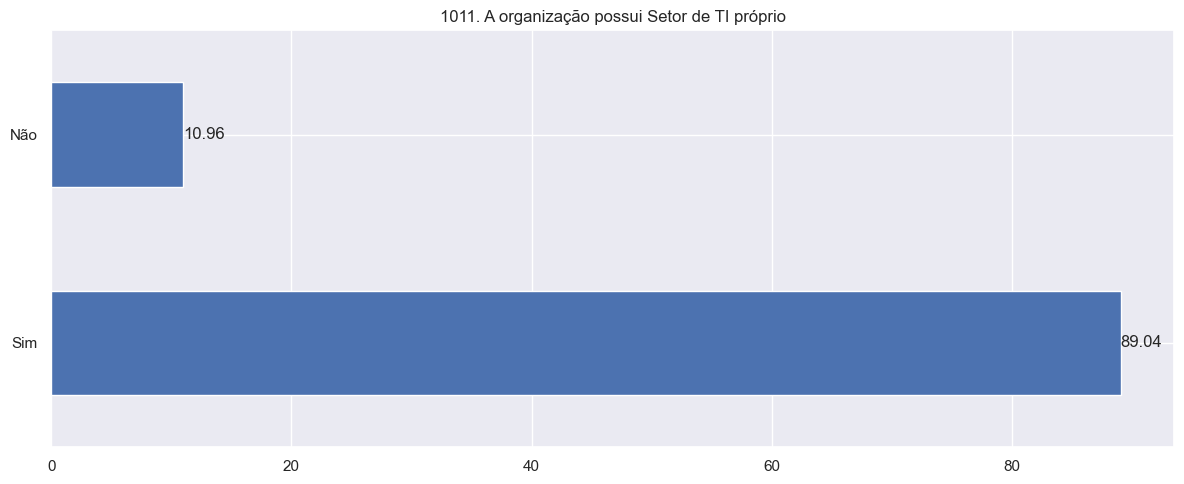

In [32]:
#1011. A organização possui Setor de TI próprio
ax = (100*df_secao_setic['q1011'].value_counts()/df_secao_setic['q1011'].count()).plot.barh(title='1011. A organização possui Setor de TI próprio', figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.tight_layout()

In [26]:
sorted(df_secao_setic[df_secao_setic['q1011'] == 'Não'].index)

['CASERJ', 'FIPERJ', 'FTMRJ', 'GVG', 'IASERJ', 'SEAS', 'SEGOV', 'TURISRIO']

In [13]:
df_secao_setic[df_secao_setic['q1011'] == 'Não'].filter(regex='^q1011nao').sort_values(by='attribute_1')

,q1011nao
attribute_1,
CASERJ,"DIRADM – Diretoria de Administração, a partir de então denominada simplesmente como DIRADM, Órgão que também participa da composição da empresa pública CA-SERJ – Companhia de Armazéns e Silos do Estado do Rio de Janeiro, inscrita no C.N.P.J. sob o nº 33.135.641/0001-02, com sede na Avenida Brasil nº 19.001, 3º andar, Irajá, Rio de Janeiro, RJ, CEP 21530-000, também, a partir de então denominada apenas como CASERJ ou COMPANHIA, então vinculada à SEAPPA – Secretaria de Estado de Agricultura, Pecuária, Pesca e Abastecimento, facilitando-se pela simples referência de denominação SEAPPA, que outrora figurou sob a antiga denominação SEDRAP – Secretaria de Estado de Desenvolvimento Regional, Abastecimento e Pesca, DIRADM esta que aqui comparece para apresentar o seu Relatório de Atividades, em razão das considerações abaixo pormenorizadas.\n\tPreliminarmente, é de se ter em importante consideração que a atual Diretoria Executiva da CASERJ assumiu a gestão da COMPANHIA, pela primeira vez, somente em dez de abril de 2019, tendo sido complementada a composição atual, pelo titular da Diretoria de Administração, apenas no ano de 2021.\n\tÉ de se destacar igualmente que apesar das intempéries que identificamos mesmo antes de aceitarmos o desafio que nos foi apresentado, jamais foram estes capazes de interromper as atividades desenvolvidas pela empresa com quem foi celebrado o Termo de Cooperação Técnica nº 001/2011 (15285824 e 17307224), a CEASA-RJ – Centrais de Abastecimento do Estado do Rio de Janeiro S/A, que em seguida será referenciada somente por CEASA.\n\tCitamos CEASA no contexto deste relatório, pois todos os empregados desta COMPANHIA foram cedidos à primeira, conforme tema retratado em sede dos processos administrativos autuados como E-06/000.026/2011, E-06/20.903/2012, E-06/21590/2012 e SEI-020005/000038/2021, que culminaram no Termo de Cooperação Técnica nº 001, de 1º de março de 2011 (documento SEI nº 17307224).\n\tPor decorrência deste, CEASA arca com Recursos próprios e oriundos da Fonte 230, para a satisfação dos custos dos benefícios trabalhistas acessórios à remuneração salarial, esta última, então suportada pelo próprio Estado do Rio de Janeiro, por movimentações financeiras / contábeis, assim, compromissos satisfeitos com Recursos da Fonte 100 (segundo o Classificador de Planejamento e Orçamento elaborado pela SE-FAZ-RJ).\n\tTudo isto se traz à colação, porque, como se observa do bojo do eletrônico E-06/20208/2011, por meio do Ofício PRESI CEASA N. 179, de 28 de abril de 2011 (7633477, folhas 02/03) e posterior manifestação PRESI desta COMPANHIA (7633477, folha 04), foram iniciados os trabalhos de possível transformação desta – naquela ocasião – cogitando-se pela possibilidade de incorporação ou fusão, pela CEASA.\n \tConforme regras estatuídas nos artigos 219, 220, 221, 222, 223 e seguintes Lei nº 6.404, de 15 de dezembro de 1976, dependem do animus dos acionistas – até unânime em certas condições – que se possa dar início ou continu..."
FIPERJ,"DE ACORDO COM O DECRETO ORGANIZACIONAL, N° 16.444 DE 1991, NECESSIDADE E PLANEJAMENTO DE MUDANÇA."
FTMRJ,"Sim, necessita. Ocorre que o Setor de TI não existe no regimento interno do òrgão. Todo o trabalho que envolve tecnologia da informação é efetuado por dois funcionário qualificados e com formação na área."
GVG,"Todo suporte de TI para a Vice-Governadoria é fornecido pela Secretaria de Estado da Casa Civil, com base no Decreto Estadual nº 45.113/2015."
IASERJ,A SECRETARIA ESTADUAL DE SAÚDE É A RESPONSÁVEL PELA ADMINISTRAÇÃO DOS RECURSOS QUE ENVOLVEM O IASERJ.
SEAS,"- A TI da Secretaria é atendida pelo Instituto Estadual do Ambiente - INEA, através de sua Gerência de Tecnologia (GERTEC);\n"
SEGOV,"Resolução Conjunta SECC/SEGOV N° 17 de 09 de março de 2021, estabelece normas de cooperação técnica entre a Secretaria de Estado da Casa Civil e a Secretaria de Estado de Governo no âmbito de suas atividades."
TURISRIO,"Pelo fato da TurisRio ser vincu

## 1021. A organização tem conhecimento dos normativos expedidos pelo Diretor Geral do SETIC (PRODERJ)

In [38]:
df_secao_setic['q1021'].value_counts()

Sim    64
Não     1
Name: q1021, dtype: int64

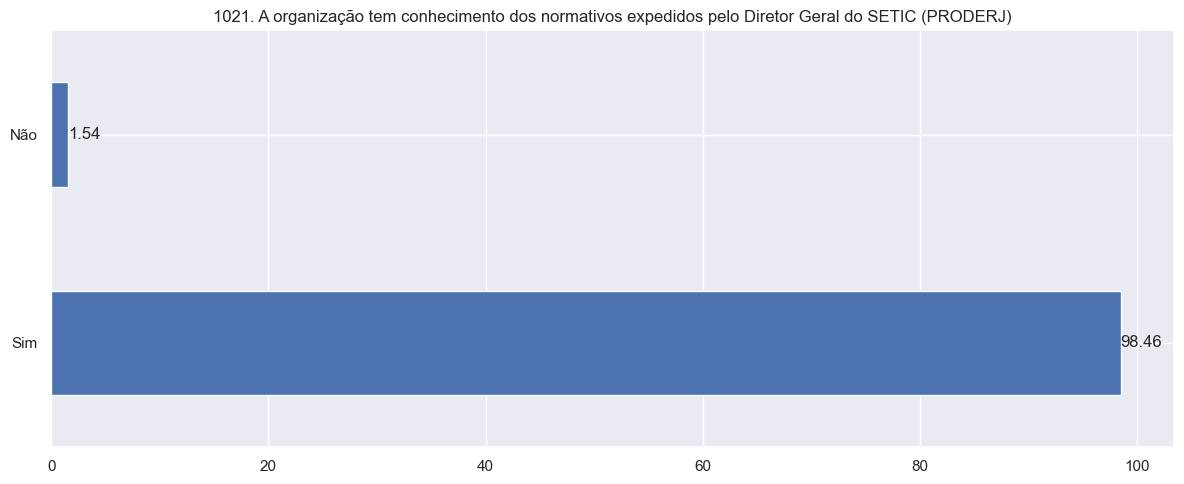

In [33]:
#1021. A organização tem conhecimento dos normativos expedidos pelo Diretor Geral do SETIC (PRODERJ)

ax = (100*df_secao_setic['q1021'].value_counts()/df_secao_setic['q1021'].count()) \
    .plot.barh(title='1021. A organização tem conhecimento dos normativos expedidos pelo Diretor Geral do SETIC (PRODERJ)', figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()

In [43]:
df_secao_setic[df_secao_setic['q1021']== 'Não'].filter(regex='^q1021')

,q1021,q1021ext[A],q1021ext[B],q1021ext[C],q1021ext[D],q1021raznao
attribute_1,,,,,,
FIA/RJ,Não,NaN,NaN,NaN,NaN,A Gestão de TI atual é nova e não teve nenhum acesso a esta documentação.


In [31]:
df_secao_setic.filter(regex='^q1021')

,q1021,q1021ext[A],q1021ext[B],q1021ext[C],q1021ext[D],q1021raznao
attribute_1,,,,,,
FAPERJ,Sim,Sim,Sim,Sim,Sim,NaN
SEAPPA,Sim,Sim,Sim,Não,Sim,NaN
TURISRIO,NaN,NaN,NaN,NaN,NaN,NaN
ISP,Sim,Sim,Sim,Sim,Sim,NaN
SEFAZ,Sim,Sim,Sim,Sim,Não,NaN
...,...,...,...,...,...,...
IASERJ,NaN,NaN,NaN,NaN,NaN,NaN
UERJ,Sim,Sim,Não,Não,Não,NaN
EMATER,Sim,Não,Sim,Não,Sim,NaN


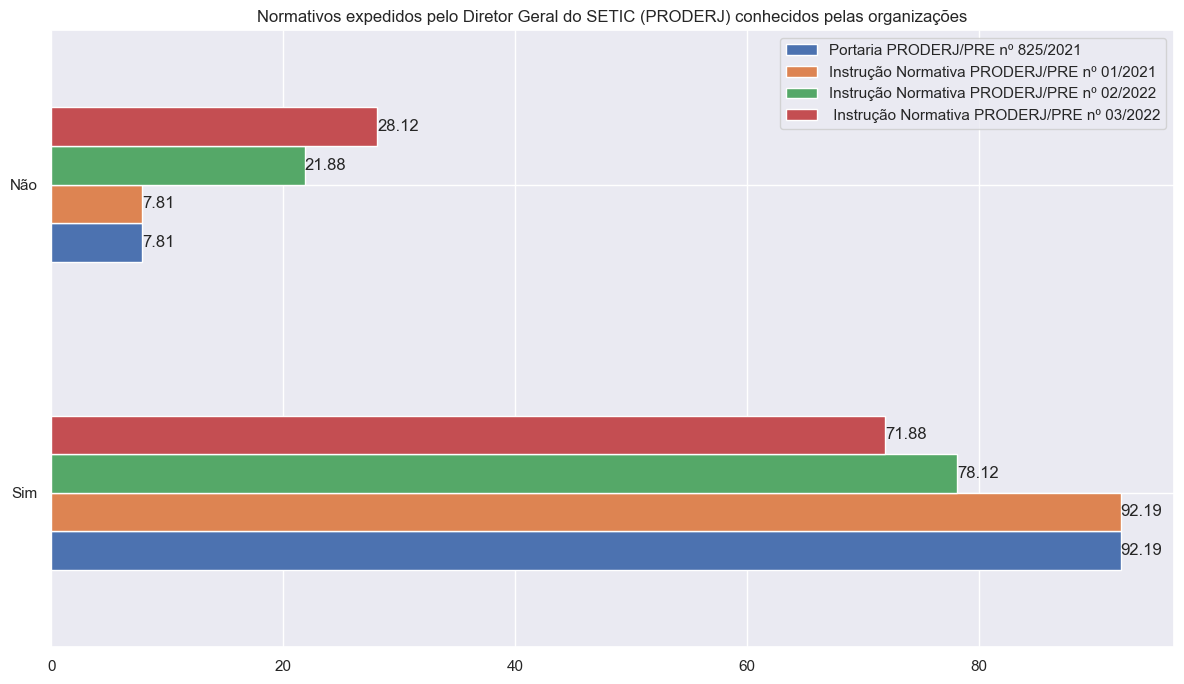

In [27]:
#Praticas mais adotadas

ax = (100*df_secao_setic.filter(regex='^q1021ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1021ext').count()) \
    .plot.barh(title='Normativos expedidos pelo Diretor Geral do SETIC (PRODERJ) conhecidos pelas organizações', figsize=(12, 7))

ax.legend(['Portaria PRODERJ/PRE nº 825/2021', 'Instrução Normativa PRODERJ/PRE nº 01/2021', 'Instrução Normativa PRODERJ/PRE nº 02/2022', ' Instrução Normativa PRODERJ/PRE nº 03/2022']);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

### 1022. A organização atende a Portaria PRODERJ/PRE nº 825/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).


In [41]:
df_secao_setic['q1022'].count()

65

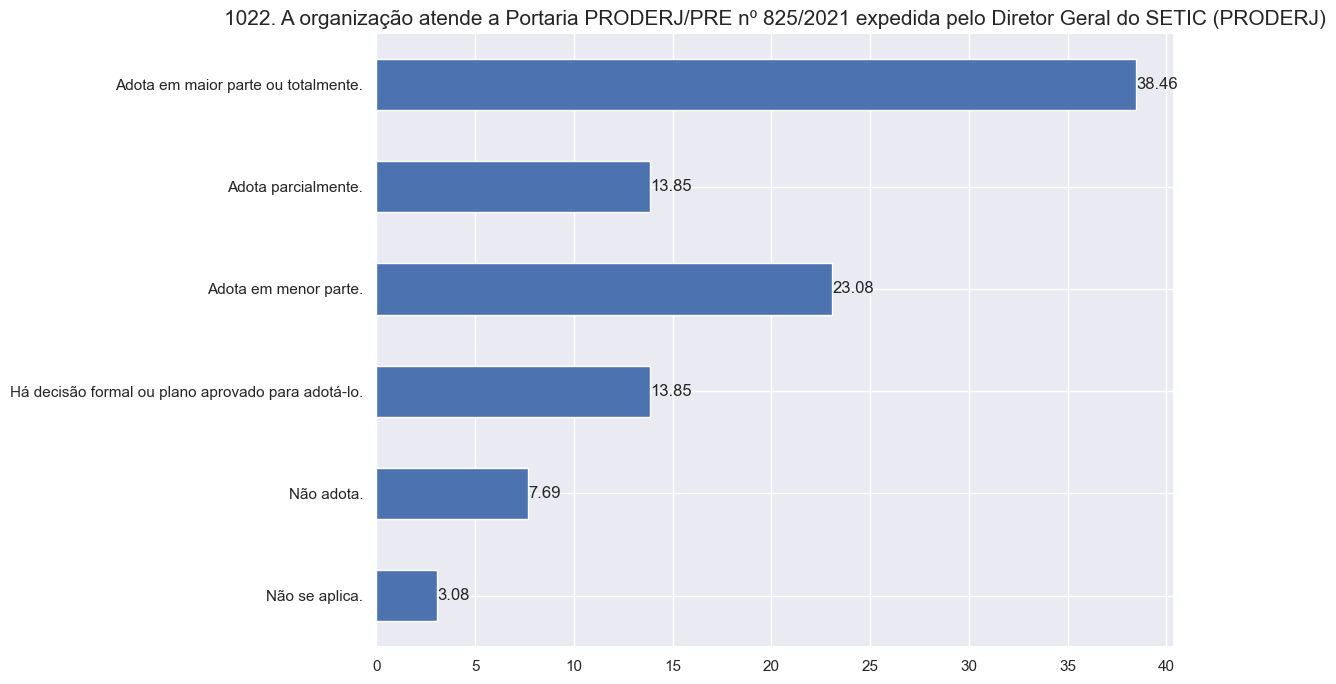

In [64]:
#1022. A organização atende a Portaria PRODERJ/PRE nº 825/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).

ax = ((100*df_secao_setic['q1022'].value_counts()/df_secao_setic['q1022'].count())[
    ['Não se aplica.', 'Não adota.', 'Há decisão formal ou plano aprovado para adotá-lo.',
    'Adota em menor parte.', 'Adota parcialmente.', 'Adota em maior parte ou totalmente.']
]) \
    .plot.barh(figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
ax.set_title('1022. A organização atende a Portaria PRODERJ/PRE nº 825/2021 expedida pelo Diretor Geral do SETIC (PRODERJ)', fontsize=15)

plt.tight_layout()

### Praticas mais adotadas


In [58]:
df_secao_setic.filter(regex='^q1022ext').count()

q1022ext[A]    34
q1022ext[B]    34
q1022ext[C]    34
q1022ext[D]    34
q1022ext[E]    34
q1022ext[F]    34
q1022ext[G]    34
dtype: int64

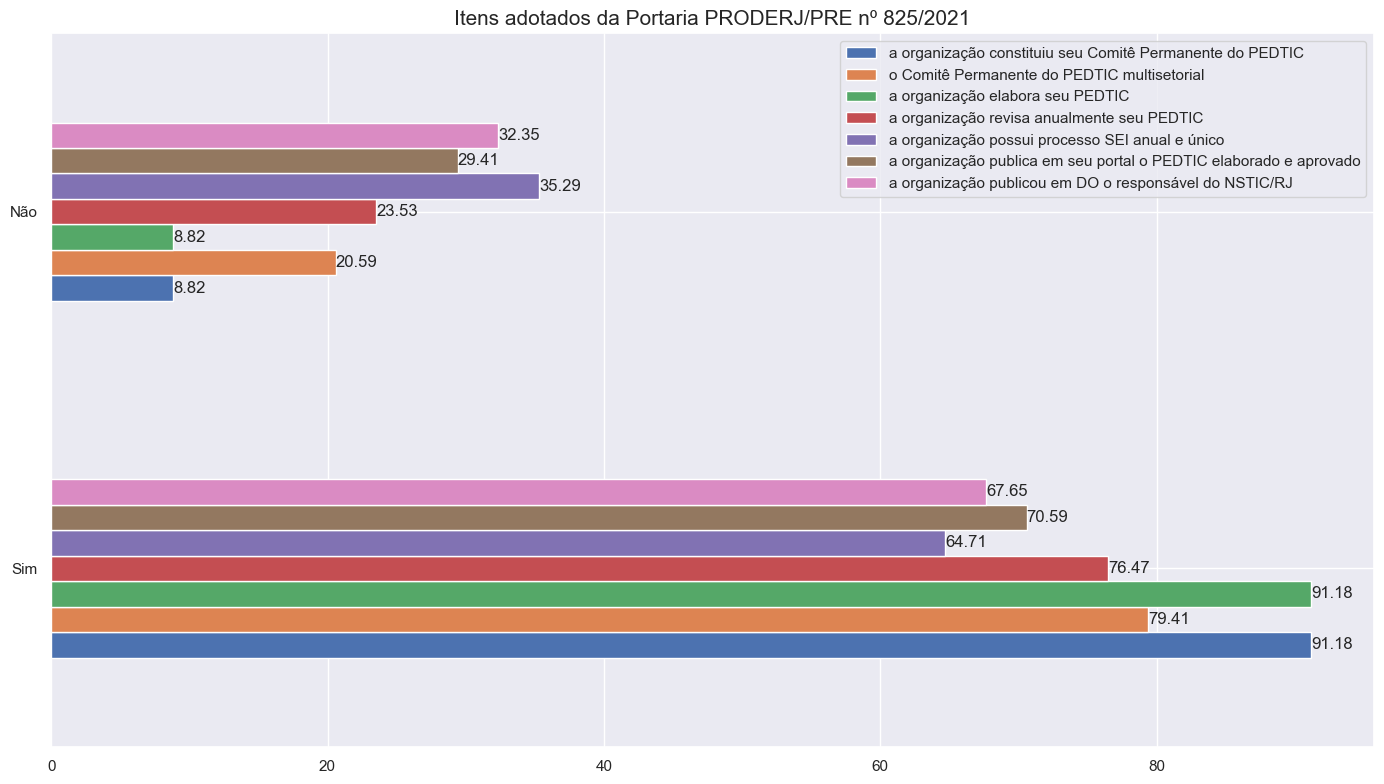

In [65]:
#Praticas mais adotadas

ax = (100*df_secao_setic.filter(regex='^q1022ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1022ext').count()) \
    .plot.barh(figsize=(14, 8))

ax.legend([
    'a organização constituiu seu Comitê Permanente do PEDTIC', 
    'o Comitê Permanente do PEDTIC multisetorial', 
    'a organização elabora seu PEDTIC', 
    'a organização revisa anualmente seu PEDTIC',
    'a organização possui processo SEI anual e único',
    'a organização publica em seu portal o PEDTIC elaborado e aprovado',
    'a organização publicou em DO o responsável do NSTIC/RJ',
]);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

ax.set_title('Itens adotados da Portaria PRODERJ/PRE nº 825/2021', fontsize=15)
plt.tight_layout()

In [54]:
#Motivos da não aplicabilidade
df_secao_setic[df_secao_setic['q1022'] == 'Não se aplica.'].filter(regex='^q1022').filter(regex='nsa|lei|est|raz')

,q1022nsa,q1022lei,q1022est,q1022raz
attribute_1,,,,
AGERIO,Não se aplica por outras razões.,NaN,NaN,"A instituição da AgeRio foi autorizada pela Lei Estadual nº 3.517, de 27 de dezembro de 2000, e concretizada através do Decreto Estadual nº 32.376, de 12 de dezembro de 2002. O Art. 1º do Decreto estabeleceu a criação da AgeRio sob a forma de sociedade anônima de economia mista, de capital fechado, autorizado, com personalidade jurídica de direito privado, autonomia administrativa e financeira. Além disso, dada a natureza não dependente da instituição, nos termos do art. 2º da Lei de Responsabilidade Fiscal (LC 101/2000), os dispostos pelos Art. 89 e Art. 90 da Lei nº 13.303, de 30 de junho de 2016 reforçam o princípio da autonomia administrativa e financeira da AgeRio. Nesse contexto, a AgeRio segue disposições próprias acerca da governança de tecnologia, sendo o Comitê de TI da instituição o órgão responsável pela discussão e opinamento sobre questões táticas e estratégicas de TI, inclusive sobre o Plano Estratégico e Diretor de TI."
PGE,"Não se aplica porque há lei e/ou norma, externa à organização, que impede a implementação desta prática.","A Constituição do ERJ, em seu Paragrafo 5 do artigo 176, na forma regulamentada pela Lei Complementar Estadual 15 de 1980, especialmente no Artigo 2, garante a autonomia administrativa e financeira da Procuradoria Geral do Estado do Rio de Janeiro. Em razão da autonomia deste Órgão, quase todos os itens da Portaria PRODERJ/PRE nº 825/2021 acabam sendo observados por serem considerados boas práticas de governança de TI. Assim, adotando a metodologia prevista para o caso de marcação do item “adota na maior parte”, este Órgão pode informar que elabora seu PEDTIC (c), revisa anualmente seu PEDTIC (d), possui processo SEI anual e único para registrar a elaboração e revisão de seu PEDTIC, assim como registrar as atas das reuniões do Comitê (e), publica em seu próprio portal o PEDTIC elaborado e aprovado (f) e publicou em Diário Oficial a indicação do principal responsável do NSTIC/RJ (g).",NaN,NaN


### 1023. A organização atende a Instrução Normativa PRODERJ/PRE nº 01/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).

In [60]:
df_secao_setic['q1023'].count()

65

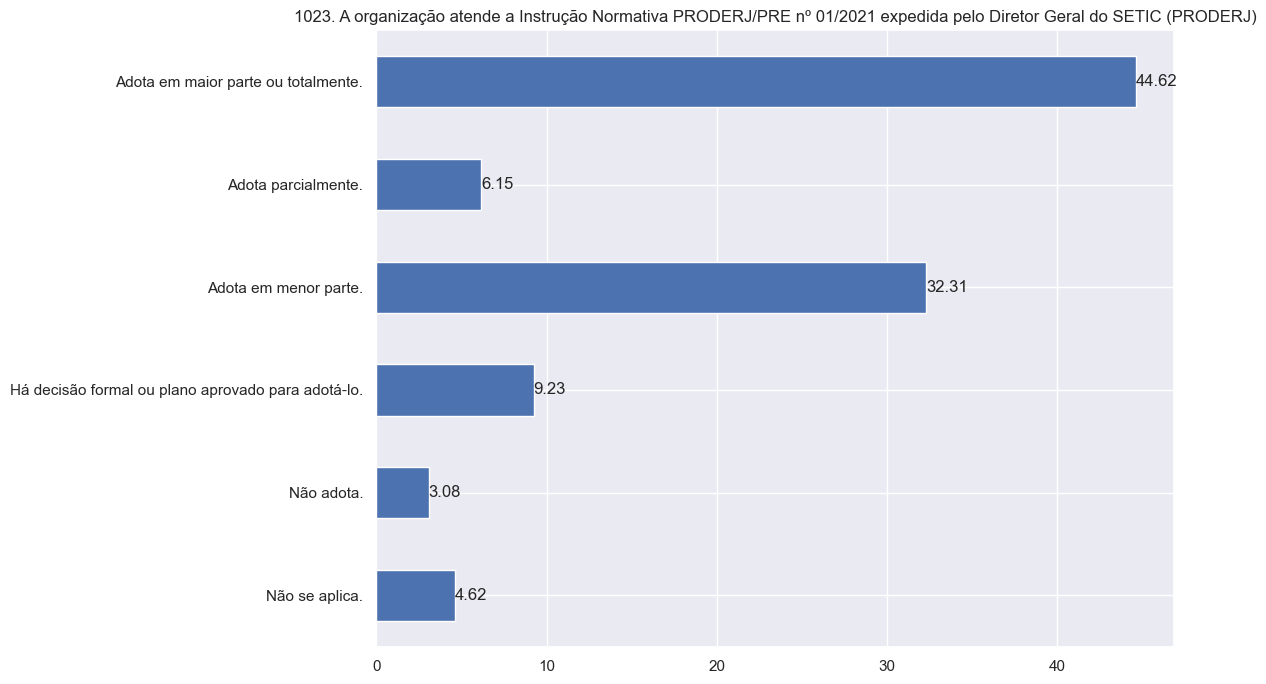

In [67]:
#1023. A organização atende a Instrução Normativa PRODERJ/PRE nº 01/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).
ax = ((100*df_secao_setic['q1023'].value_counts()/df_secao_setic['q1023'].count())[
    ['Não se aplica.', 'Não adota.', 'Há decisão formal ou plano aprovado para adotá-lo.',
    'Adota em menor parte.', 'Adota parcialmente.', 'Adota em maior parte ou totalmente.']
]) \
    .plot.barh(title='1023. A organização atende a Instrução Normativa PRODERJ/PRE nº 01/2021 expedida pelo Diretor Geral do SETIC (PRODERJ)', figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

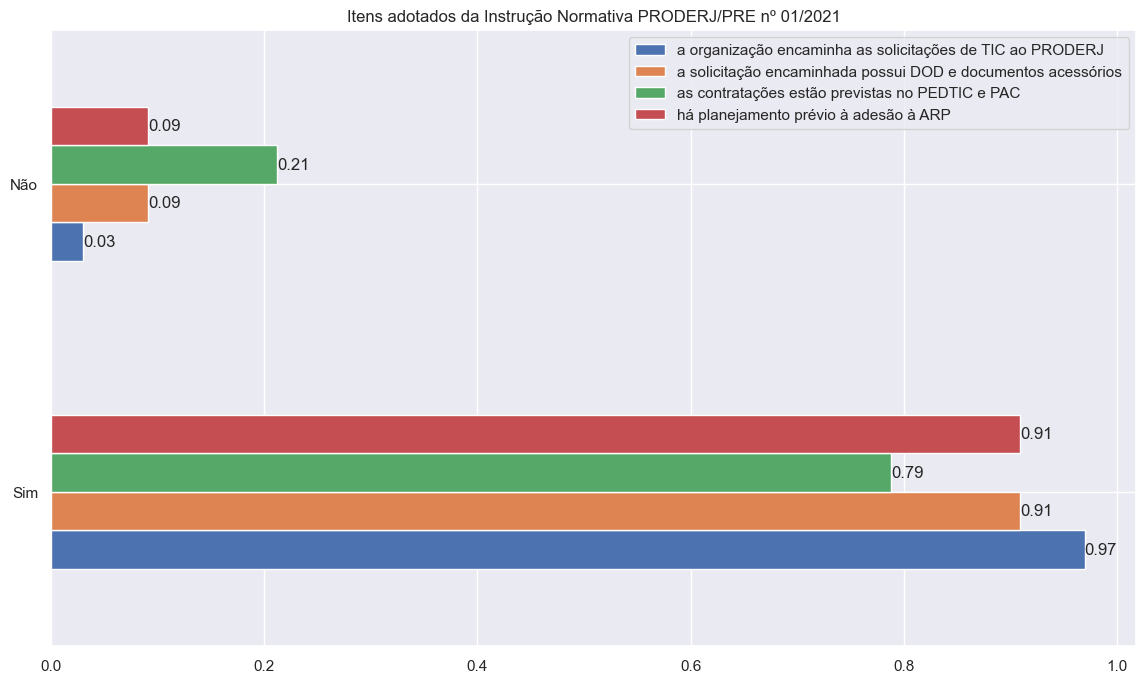

In [68]:
#Praticas mais adotadas
df_secao_setic.filter(regex='^q1023ext').apply(pd.value_counts)

ax = (df_secao_setic.filter(regex='^q1023ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1023ext').count()) \
    .plot.barh(title='Itens adotados da Instrução Normativa PRODERJ/PRE nº 01/2021', figsize=(14, 8))

ax.legend([
    'a organização encaminha as solicitações de TIC ao PRODERJ', 
    'a solicitação encaminhada possui DOD e documentos acessórios', 
    'as contratações estão previstas no PEDTIC e PAC', 
    'há planejamento prévio à adesão à ARP'    
]);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

In [56]:
#Motivos da não aplicabilidade
df_secao_setic[df_secao_setic['q1023'] == 'Não se aplica.'].filter(regex='^q1023').filter(regex='nsa|lei|est|raz')

,q1023nsa,q1023lei,q1023est,q1023raz
attribute_1,,,,
AGERIO,"Não se aplica porque há lei e/ou norma, externa à organização, que impede a implementação desta prática.","A instituição da AgeRio foi autorizada pela Lei Estadual nº 3.517, de 27 de dezembro de 2000, e concretizada através do Decreto Estadual nº 32.376, de 12 de dezembro de 2002. O Art. 1º do Decreto estabeleceu a criação da Agência sob a forma de sociedade anônima de economia mista, de capital fechado, autorizado, com personalidade jurídica de direito privado, autonomia administrativa e financeira. Além disso, dada a natureza não dependente da instituição, nos termos do art. 2º da Lei de Responsabilidade Fiscal (LC 101/2000), os dispostos pelos Art. 89 e Art. 90 da Lei nº 13.303, de 30 de junho de 2016 reforçam o princípio da autonomia administrativa e financeira da Agência. Nesse contexto, a AgeRio segue disposições próprias acerca da governança de tecnologia, sendo o Comitê de TI da instituição o órgão responsável pela discussão e opinamento sobre questões táticas e estratégicas de TI, inclusive sobre o Plano Estratégico e Diretor de TI.",NaN,NaN
PGE,"Não se aplica porque há lei e/ou norma, externa à organização, que impede a implementação desta prática.","A Constituição do ERJ, em seu Paragrafo 5 do artigo 176, na forma regulamentada pela Lei Complementar Estadual 15 de 1980, especialmente no Artigo 2, garante a autonomia administrativa e financeira da Procuradoria Geral do Estado do Rio de Janeiro.",NaN,NaN
FLXIII,Não se aplica por outras razões.,NaN,NaN,Não possui


### 1024. A organização atende a Instrução Normativa PRODERJ/PRE nº 02/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).

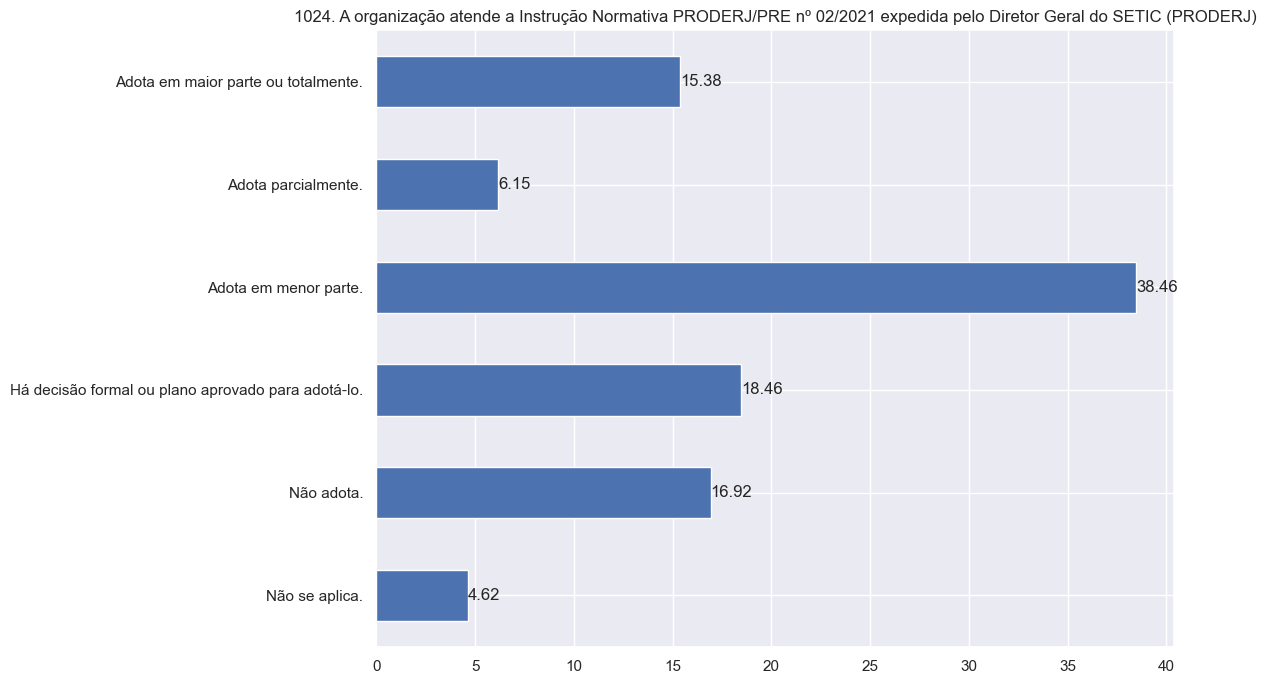

In [69]:
#1024. A organização atende a Instrução Normativa PRODERJ/PRE nº 02/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).

ax = ((100*df_secao_setic['q1024'].value_counts()/df_secao_setic['q1024'].count())[
    ['Não se aplica.', 'Não adota.', 'Há decisão formal ou plano aprovado para adotá-lo.',
    'Adota em menor parte.', 'Adota parcialmente.', 'Adota em maior parte ou totalmente.']
]) \
    .plot.barh(title='1024. A organização atende a Instrução Normativa PRODERJ/PRE nº 02/2021 expedida pelo Diretor Geral do SETIC (PRODERJ)', figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

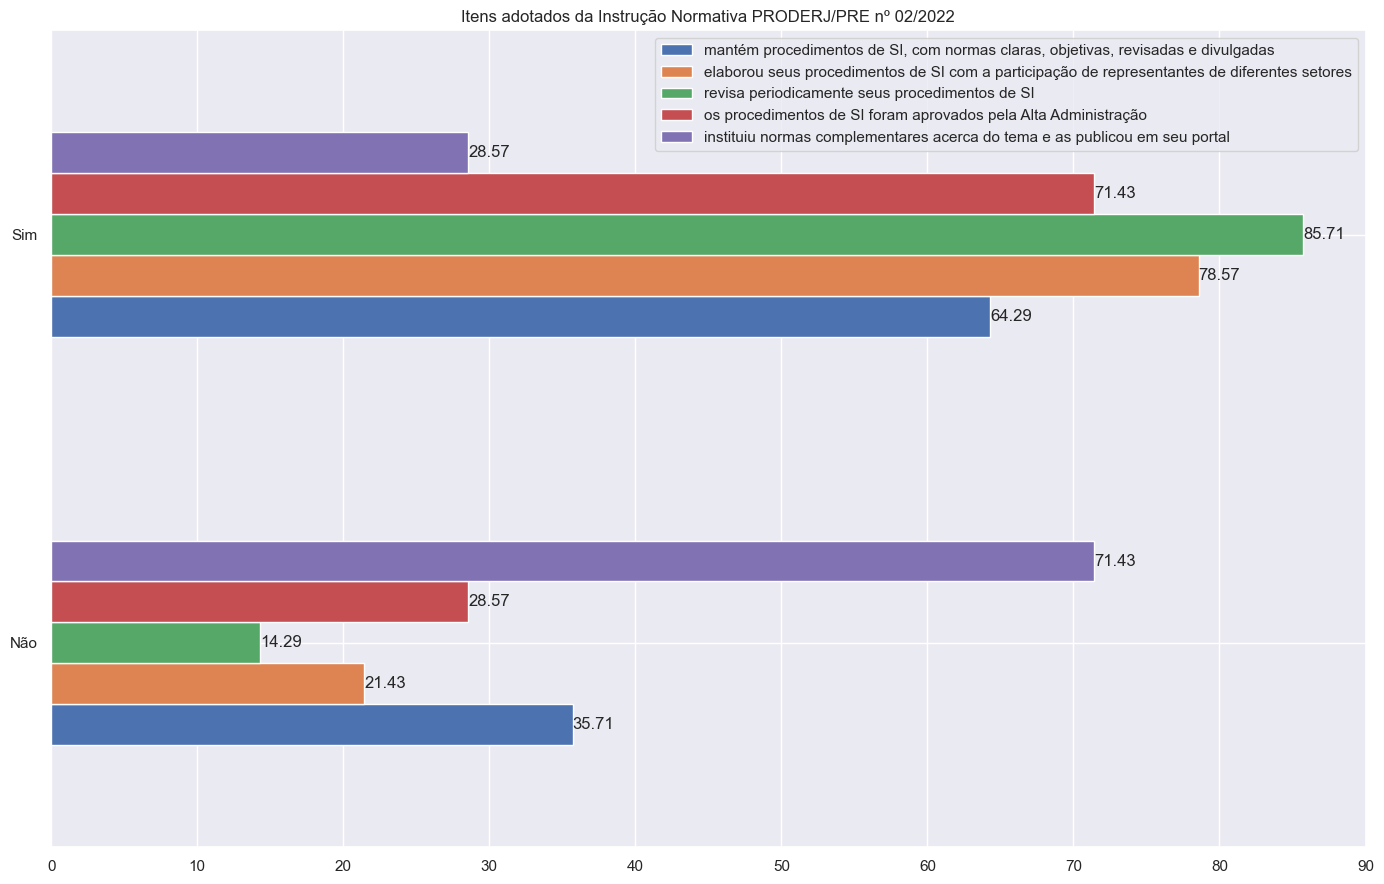

In [87]:
#Praticas mais adotadas
ax = (100*df_secao_setic.filter(regex='^q1024ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1024ext').count()) \
    .plot.barh(title='Itens adotados da Instrução Normativa PRODERJ/PRE nº 02/2022', figsize=(14, 9))

ax.legend([
    'mantém procedimentos de SI, com normas claras, objetivas, revisadas e divulgadas', 
    'elaborou seus procedimentos de SI com a participação de representantes de diferentes setores', 
    'revisa periodicamente seus procedimentos de SI', 
    'os procedimentos de SI foram aprovados pela Alta Administração',
    'instituiu normas complementares acerca do tema e as publicou em seu portal'
]);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

In [59]:
#Motivos da não aplicabilidade
df_secao_setic[df_secao_setic['q1024'] == 'Não se aplica.'].filter(regex='^q1024').filter(regex='nsa|lei|est|raz')

,q1024nsa,q1024lei,q1024est,q1024raz
attribute_1,,,,
SETD,Não se aplica por outras razões.,NaN,NaN,"A Secretaria de Estado de Transformação Digital (SETD) foi criada por meio do Decreto Estadual nº 48.151, de 08 de julho de 2022, e foi estruturada pelo Decreto Estadual nº 48.378, de 01 de março de 2023. A partir disso, iniciaram-se as operações com as competências definidas, a estrutura organizada e com recursos necessários. A SETD, por estar utilizando o mesmo ambiente e infraestrutura do PRODERJ, emprega todos os instrumentos de segurança da informação e procedimentos operacionais já disponibilizados pela instituição. Mesmo assim, existe orientação para a devida adoção de procedimentos quanto às questões de segurança da informação por parte da Secretaria, logo após as aprovações do PEI e do PEDTIC."
PGE,"Não se aplica porque há lei e/ou norma, externa à organização, que impede a implementação desta prática.","A Constituição do ERJ, em seu Paragrafo 5 do artigo 176, na forma regulamentada pela Lei Complementar Estadual 15 de 1980, especialmente no Artigo 2, garante a autonomia administrativa e financeira da Procuradoria Geral do Estado do Rio de Janeiro. Em razão da autonomia deste Órgão, parte dos itens da Instrução Normativa PRODERJ/PRE nº 02/2021 são adotados por serem considerados boas práticas de segurança da informação. Assim, adotando a metodologia prevista para o caso de marcação do item “adota na maior parte”, este Órgão pode informar que revisa periodicamente seus procedimentos de segurança da informação (c) e que os procedimentos de segurança da informação foram aprovados pela Alta Administração deste Órgão (d).",NaN,NaN
FLXIII,Não se aplica por outras razões.,NaN,NaN,Não possui


### 1025. A organização desenvolve, sustenta e/ou hospeda seu site ou portal nos ambientes do PRODERJ.


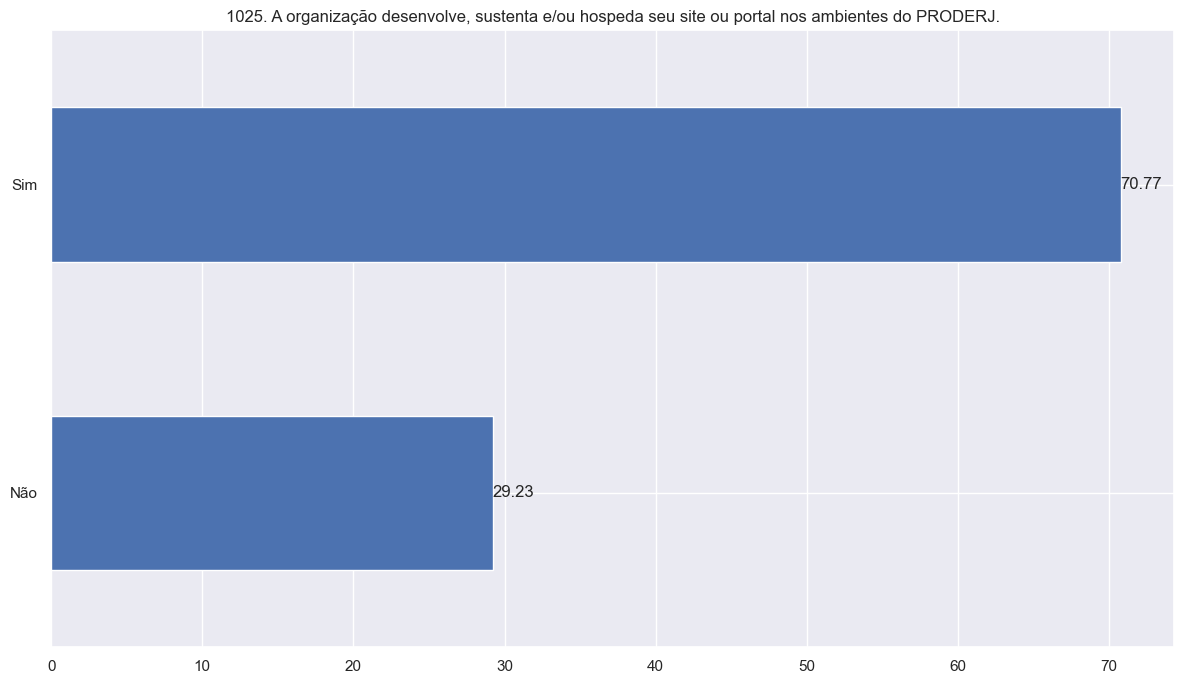

In [84]:
#1025. A organização desenvolve, sustenta e/ou hospeda seu site ou portal nos ambientes do PRODERJ.

ax = ((100*df_secao_setic['q1025'].value_counts()/df_secao_setic['q1025'].count())[['Não', 'Sim']]) \
    .plot.barh(title='1025. A organização desenvolve, sustenta e/ou hospeda seu site ou portal nos ambientes do PRODERJ.', figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

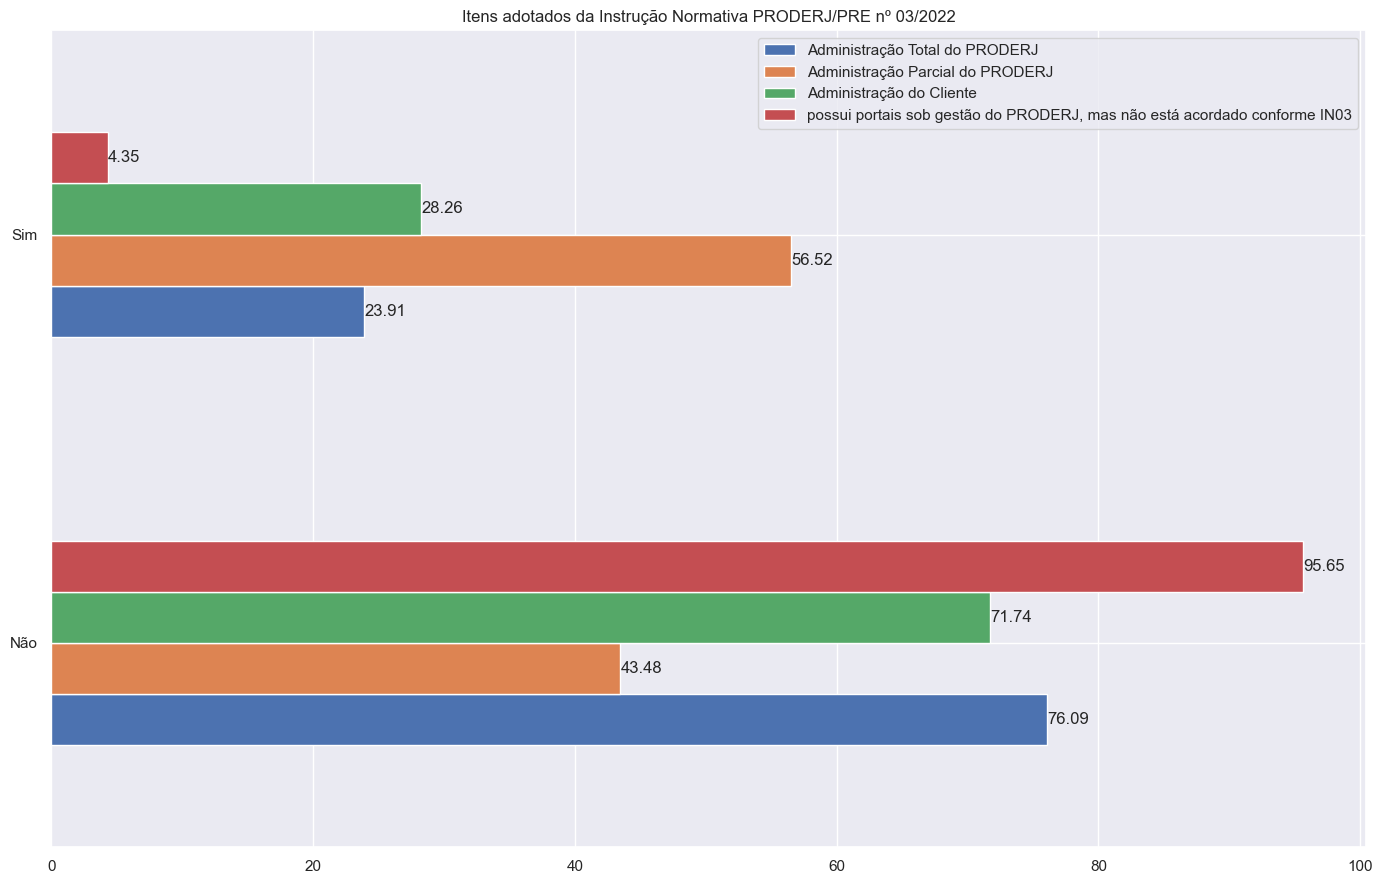

In [86]:
#Praticas mais adotadas
df_secao_setic.filter(regex='^q1025ext').apply(pd.value_counts)

ax = (100*df_secao_setic.filter(regex='^q1025ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1025ext').count()) \
    .plot.barh(title='Itens adotados da Instrução Normativa PRODERJ/PRE nº 03/2022', figsize=(14, 9))

ax.legend([
    'Administração Total do PRODERJ', 
    'Administração Parcial do PRODERJ', 
    'Administração do Cliente', 
    'possui portais sob gestão do PRODERJ, mas não está acordado conforme IN03'
]);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

In [88]:
#Motivos da não utilização
df_secao_setic[df_secao_setic['q1025'] == 'Não'].filter(regex='^q1025raz')

,q1025raznao
attribute_1,
FAPERJ,No momento existe um estudo para migrar alguns serviços para o PRODERJ.
SEFAZ,A SEFAZ/RJ desenvolve e sustenta sites e portais em ambiente próprio.
DETRO,"Devido a troca de gestão, eu, na qualidade de Coordenadora desta COOTI, cumpro mencionar que assumi a T.I desta autarquia em 17 de Janeiro de 2023, todavia estamos adotando medidas cabíveis para melhor atender o orgão."
FSC,Site não homologado - WORDPRESS
CODIN,"A CODIN mantém site externo em provedor particular, com informações necessárias às atividades da empresa e mantém site interno (Intranet) para os serviços previstos para os colaboradores."
SEDEC,Nosso órgão possui servidor próprio.
JUCERJA,SOMENTE O DOMÍNIO É GERIDO PELO PRODERJ.
DETRAN,O DETRAN sempre possuiu infraestrutura própria apartada do PRODERJ.
AGERIO,"Por conta da autonomia administrativa da agência conforme detalhado nas respostas anteriores, a saber: A instituição da AgeRio foi autorizada pela Lei Estadual nº 3.517, de 27 de dezembro de 2000, e concretizada através do Decreto Estadual nº 32.376, de 12 de dezembro de 2002. O Art. 1º do Decreto estabeleceu a criação da Agência sob a forma de sociedade anônima de economia mista, de capital fechado, autorizado, com personalidade jurídica de direito privado, autonomia administrativa e financeira. Além disso, dada a natureza não dependente da instituição, nos termos do art. 2º da Lei de Responsabilidade Fiscal (LC 101/2000), os dispostos pelos Art. 89 e Art. 90 da Lei nº 13.303, de 30 de junho de 2016 reforçam o princípio da autonomia administrativa e financeira da Agência. Nesse contexto, a AgeRio segue disposições próprias acerca da governança de tecnologia, sendo o Comitê de TI da instituição o órgão responsável pela discussão e opinamento sobre questões táticas e estratégicas de TI, inclusive sobre o Plano Estratégico e Diretor de TI."


# Avaliação de satisfação das organizações quanto ao SETIC

### 1031. Nos últimos doze meses, o Gestor de TI recebeu comunicações do Diretor Geral do SETIC (PRODERJ)?

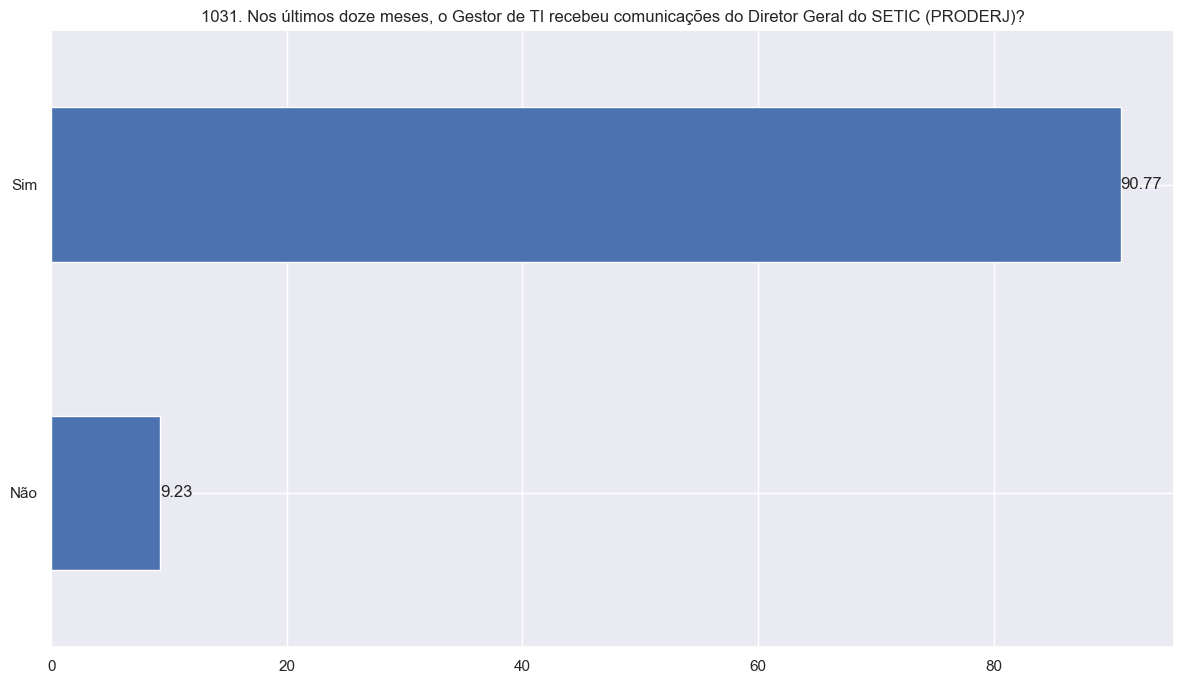

In [89]:
#1031. Nos últimos doze meses, o Gestor de TI recebeu comunicações do Diretor Geral do SETIC (PRODERJ)?

ax = ((100*df_secao_setic['q1031'].value_counts()/df_secao_setic['q1031'].count())[['Não', 'Sim']]) \
    .plot.barh(title='1031. Nos últimos doze meses, o Gestor de TI recebeu comunicações do Diretor Geral do SETIC (PRODERJ)?', figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

In [126]:
df_secao_setic[df_secao_setic['q1031'] == 'Não'].filter(regex='^q1031')

,q1031
attribute_1,
FSC,Não
CODIN,Não
CEASA,Não
JUCERJA,Não
AGETRANSP,Não
EMATER,Não


### 1032. Considerando os meios de comunicação disponibilizadas pelo Diretor Geral (PRODERJ), qual a satisfação do Gestor de TI em relação à relevância da comunicação do Diretor Geral com os órgãos setoriais no SETIC?


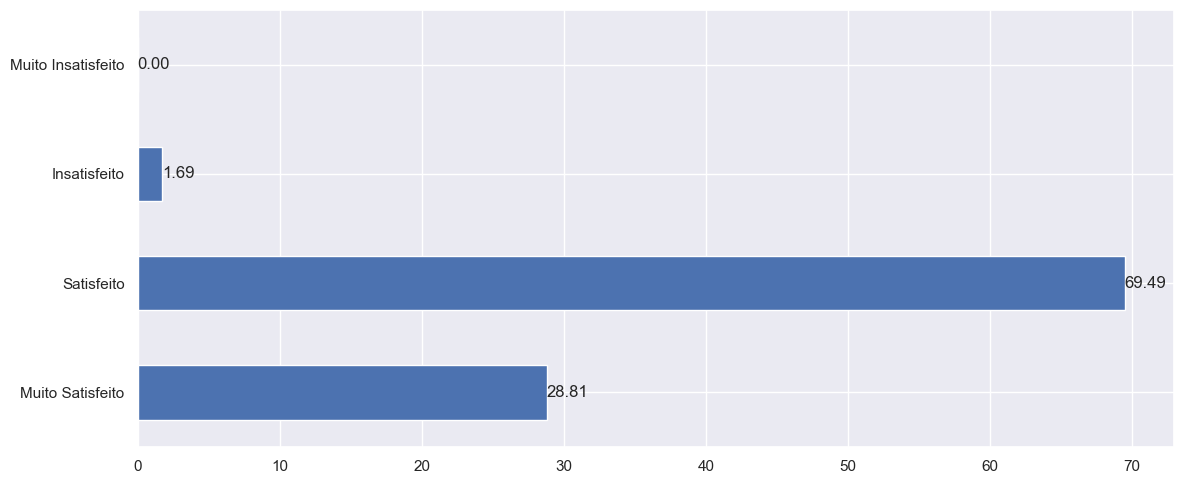

In [106]:
#1032. Considerando os meios de comunicação disponibilizadas pelo Diretor Geral (PRODERJ), qual a satisfação
#do Gestor de TI em relação à relevância da comunicação do Diretor Geral com os órgãos setoriais no SETIC?

dictionary = {'Muito Satisfeito': 0, 'Satisfeito': 0, 'Insatisfeito': 0, 'Muito Insatisfeito': 0}
dados = pd.DataFrame.from_dict({**dictionary, **df_secao_setic['q1032'].value_counts().to_dict()}, orient='index')

ax = ((100*dados/df_secao_setic['q1032'].count())) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

ax.get_legend().set_visible(False)

plt.tight_layout()

### Todas as opiniões acerca da relevância da comunicação do Diretor Geral

In [105]:
df_secao_setic.filter(regex='^q1032')

,q1032,q1032raz
attribute_1,,
FAPERJ,Muito Satisfeito,Superior as expectativas.
SEAPPA,Satisfeito,"Como fui definido recentemente como o Gestor do TI do orgão SEAPPA, estou avaliando de acordo com as demandas que realizei junto ao PRODERJ."
TURISRIO,NaN,NaN
ISP,Satisfeito,"Participamos de grupos no WhatsApp para assessores de TIC, onde são passadas informações, esclarecimentos e solicitações, bem como para o PEDTIC, Recebemos ocasionalmente e quando necessário, informações através de e-mails e ligações telefônicas."
SEFAZ,Satisfeito,"Informações importantes, como PLS, são avisadas sem antecedência adequada. Não há comunicação durante a fase de elaboração do TR."
...,...,...
IASERJ,NaN,NaN
UERJ,Satisfeito,"Embora não tenhamos necessidade de orientação ou auxilio do PRODERJ, considerando a relação de\nparceria histórica desenvolvida entre o PRODERJ e a UERJ, estamos satisfeitos"
EMATER,NaN,NaN


In [107]:
df_secao_setic[
    (df_secao_setic['q1032'] == 'Insatisfeito') | 
    (df_secao_setic['q1032'] == 'Muito Insatisfeito')
].filter(regex='^q1032')

,q1032,q1032raz
attribute_1,,
SEEDUC,Insatisfeito,"Embora os meios de comunicação sejam diversificados, alguns processos relevantes não perpassam aos veículos habituais e oficiais de comunicação com as áreas técnicas das SEEDUC-RJ, em que demandas formais, muitas das vezes são abordadas no grupo de 'WhatsApp'. A título de exemplo, citam-se os planos de suprimentos, que deveriam ser tratados por intermédio dos canais de compras públicas RJ e/ou pela interface do SIGA ou Rede Logística com envio de mensagem quando da criação de novos PLS. Em que pese os mecanismos de desburocratização, de fato, algumas oportunidades são perdidas por essa questão."


In [185]:
aux = df_secao_setic['q1032']
aux = aux.replace({'Muito Satisfeito': 4, 'Satisfeito': 3, 'Insatisfeito': 2, 'Muito Insatisfeito': 1})
aux.describe()

count    59.000000
mean      3.271186
std       0.485319
min       2.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       4.000000
Name: q1032, dtype: float64

Text(0.5, 0, 'Valores de cada resposta')

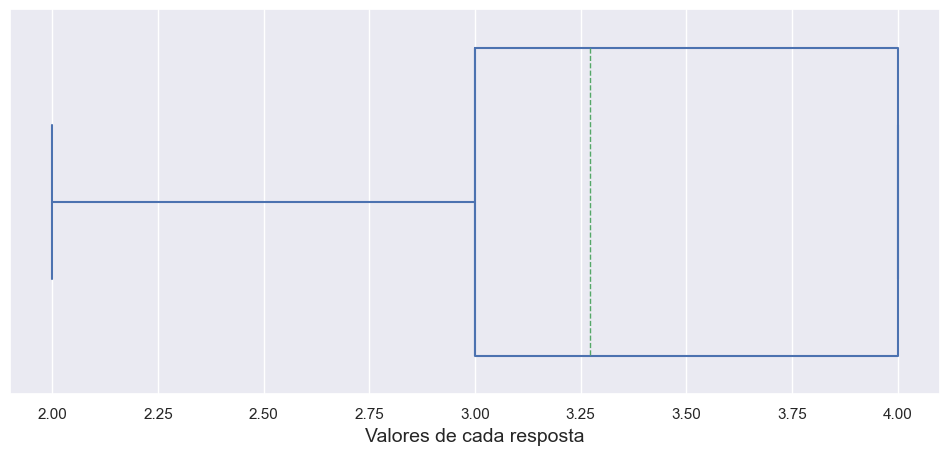

In [187]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
sns.boxplot(x=aux, fill=False, showmeans=True,  meanline=True, ax=ax)

plt.xlabel("Valores de cada resposta", size=14)

### 1033. Nos últimos doze meses, o Gestor de TI recebeu auxílio e/ou orientação do Diretor Geral do SETIC (PRODERJ)?

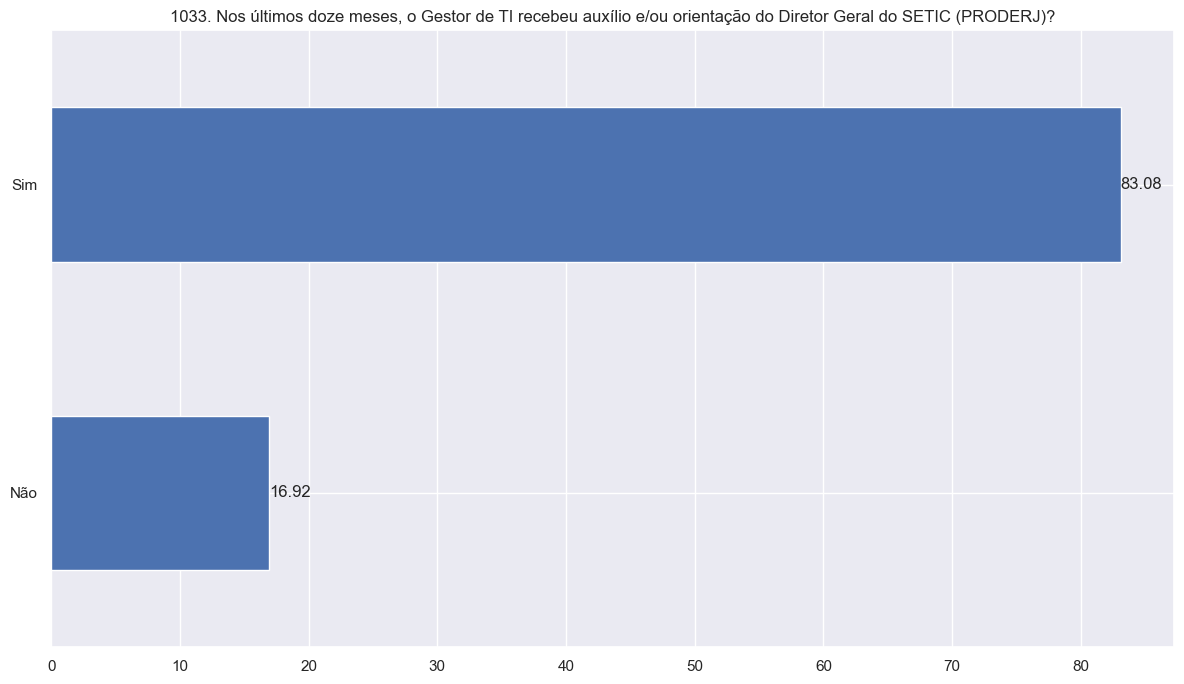

In [131]:
#1033. Nos últimos doze meses, o Gestor de TI recebeu auxílio e/ou orientação do Diretor Geral do SETIC (PRODERJ)?

ax = ((100*df_secao_setic['q1033'].value_counts()/df_secao_setic['q1033'].count())[['Não', 'Sim']]) \
    .plot.barh(title='1033. Nos últimos doze meses, o Gestor de TI recebeu auxílio e/ou orientação do Diretor Geral do SETIC (PRODERJ)?', figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

### 1034. Qual a satisfação do Gestor de TI em relação ao auxílio e orientação prestados pelo Diretor Geral (PRODERJ) aos órgãos setoriais do SETIC?

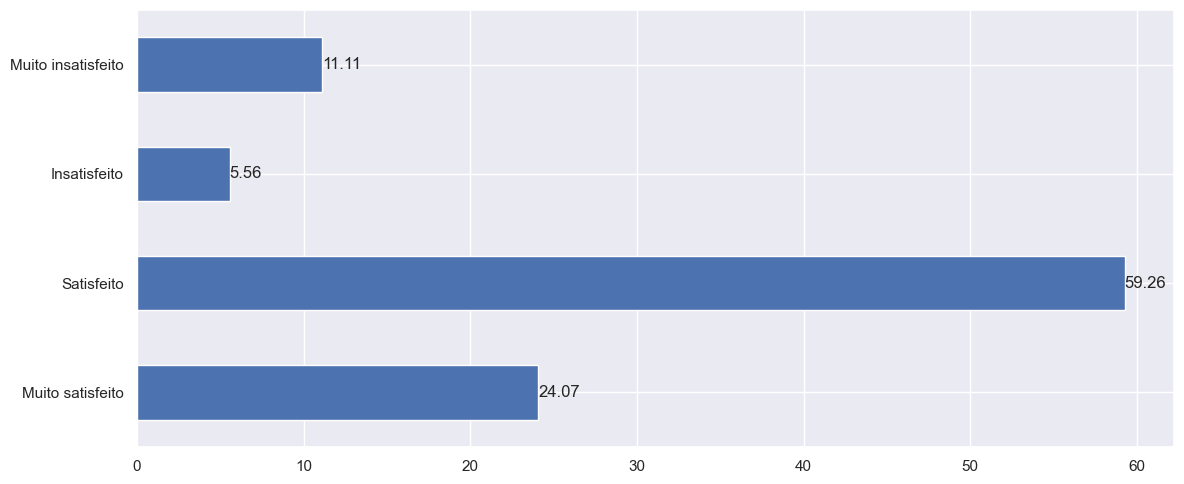

In [132]:
#1034. Qual a satisfação do Gestor de TI em relação ao auxílio e orientação prestados pelo Diretor Geral (PRODERJ)
#aos órgãos setoriais do SETIC?

dictionary = {'Muito satisfeito': 0, 'Satisfeito': 0, 'Insatisfeito': 0, 'Muito insatisfeito': 0}
dados = pd.DataFrame.from_dict({**dictionary, **df_secao_setic['q1034'].value_counts().to_dict()}, orient='index')

ax = ((100*dados/df_secao_setic['q1034'].count())) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

ax.get_legend().set_visible(False)

plt.tight_layout()

In [140]:
df_secao_setic.filter(regex='^q1034')

,q1034,q1034raz
attribute_1,,
FAPERJ,Muito insatisfeito,Superior as expectativas.
SEAPPA,Satisfeito,"Em todos as demandas encontradas durante os primeiros dias no cargo, fui atendido e orientado com muito respeito e atenção."
TURISRIO,NaN,NaN
ISP,Satisfeito,"Na sua maioria, as informações são claramente passadas e as questões resolvidas. Algumas merecem mais atenção em relação ao tempo de resposta e sobre a quem compete tratar de determinada questão."
SEFAZ,Satisfeito,"Recebemos orientações do processo de elaboração e revisão do PEDTIC e da Academia PRODERJ, que é muito boa."
...,...,...
IASERJ,NaN,NaN
UERJ,NaN,NaN
EMATER,Satisfeito,O recebimento de orientações para contratações de TIC é muito importante no momento da contratação.


#### Casos de insatisfação

In [141]:
df_secao_setic[
    (df_secao_setic['q1034'] == 'Insatisfeito') | 
    (df_secao_setic['q1034'] == 'Muito insatisfeito')
].filter(regex='^q1034').index

,q1034,q1034raz
attribute_1,,
FAPERJ,Muito insatisfeito,Superior as expectativas.
SETUR,Muito insatisfeito,"Todas as vezes que precisei de ajuda , o PRODERJ imediatamente entrou em contato comigo, por ligação, whatsapp ou e-mail, nunca tive reclamações do pesso do PRODERJ, só tenho elogios."
IPEM/RJ,Muito insatisfeito,A equipe do Proderj encontra-se disponível principalmente pelo whatsapp e por e-mail onde podemos tirar dúvidas e conseguir orientações na medida do possível.
EMOP,Insatisfeito,"O PRODERJ nos oferece cursos gratuitos online com muita relevância, existe um grupo específico para elaboração do PEDTIC, eventos e reuniões refrente a área de TIC"
SEDEC,Muito insatisfeito,Sempre esteve à disposição para resolver os problemas que surgem ao longo do ano.
IRM,Insatisfeito,"Toda dúvida em que o IRM teve sempre obtivemos uma atenção na tratativa, tanto por telefone, email e whatsapp. Nas diversas áreas do Proderj."
DETRAN,Muito insatisfeito,Em todas as consultas e solicitações feitas o PRODERJ sempre foi solicito e eficiente em suas respostas.
FAETEC,Muito insatisfeito,"SUPORTE QUE ME É DADO PELO LIDER DE ATENDIMENTO SR. SÉRGIO CASTRO A MINHA INSTITUIÇÃO, É INSTANTANEA, TANTO POR MAIL , CELULAR, WHATS APP. EM TODOS OS CASO FOI SOLUCIONADO 100%, COM RAPIDEZ E EFETIVIDADE. SUPREENDENDO AS ESPECTATIVAS."
UENF,Insatisfeito,O PRODERJ sempre se mostrou acessível.


In [138]:
aux = df_secao_setic['q1034']
aux = aux.replace({'Muito satisfeito': 4, 'Satisfeito': 3, 'Insatisfeito': 2, 'Muito insatisfeito': 1})
aux.describe()

count    54.000000
mean      2.962963
std       0.867940
min       1.000000
25%       3.000000
50%       3.000000
75%       3.000000
max       4.000000
Name: q1034, dtype: float64

#### Ajustando os casos de preenchimento errado, uma vez que as justificativas foram todas positivas e a resposta havia sido marcada com sentido negativo

In [188]:
aux = df_secao_setic['q1034']
aux = aux.replace({'Muito insatisfeito': 'Muito satisfeito', 'Insatisfeito': 'Satisfeito'})
aux = aux.replace({'Muito satisfeito': 4, 'Satisfeito': 3, 'Insatisfeito': 2, 'Muito insatisfeito': 1})
aux.describe()

count    54.000000
mean      3.351852
std       0.482032
min       3.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       4.000000
Name: q1034, dtype: float64

Text(0.5, 0, 'Valores de cada resposta')

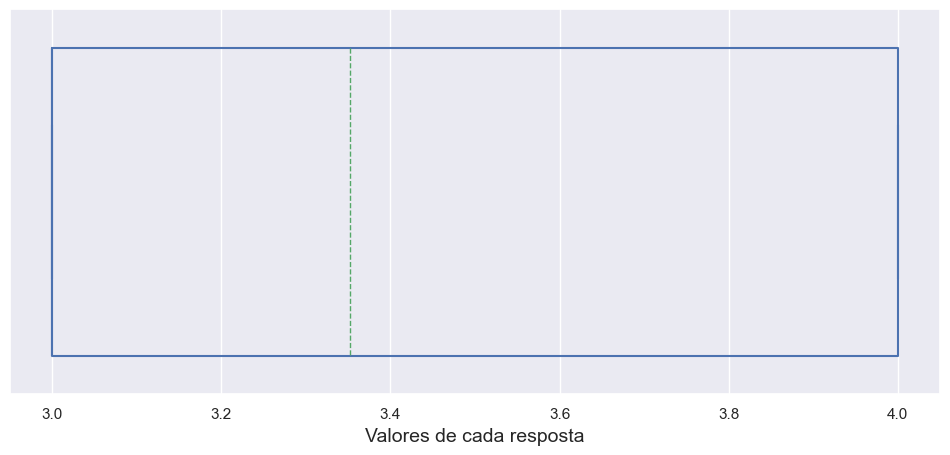

In [190]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
sns.boxplot(x=aux, fill=False, showmeans=True, meanline=True, ax=ax)

plt.xlabel("Valores de cada resposta", size=14)

### 1035. As boas práticas de TIC induzidas pelo Diretor Geral do SETIC (PRODERJ) aos órgãos setoriais ajudaram o Gestor de TI a lidar com seus problemas? 

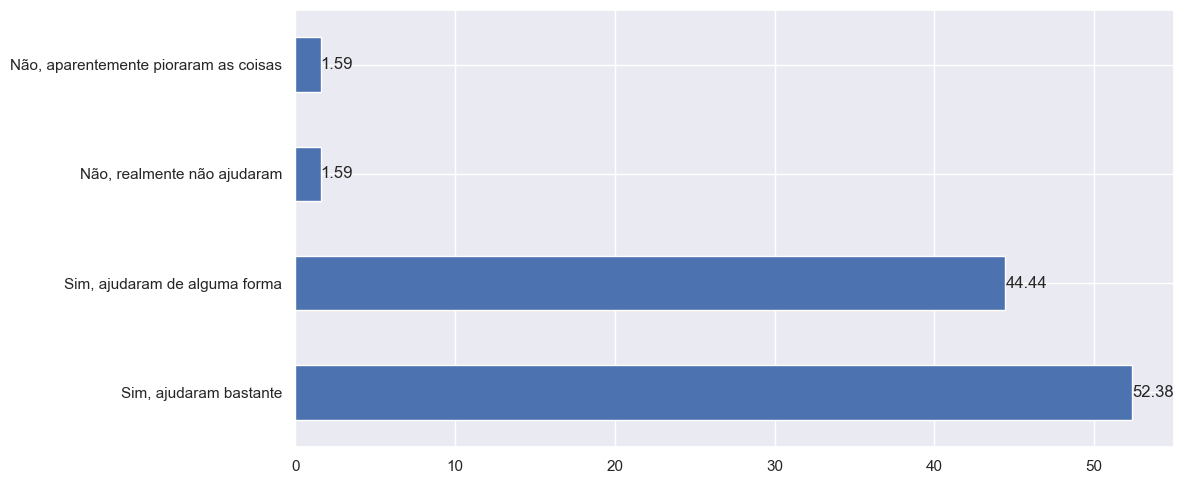

In [146]:
#1035. As boas práticas de TIC induzidas pelo Diretor Geral do SETIC (PRODERJ) aos órgãos setoriais ajudaram o
#Gestor de TI a lidar com seus problemas? 

aux = df_secao_setic[df_secao_setic['q1035'] != 'Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)']['q1035']


ax = ((100*aux.value_counts()/aux.count())) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()

In [149]:
df_secao_setic.filter(regex='^q1035')

,q1035,q1035raz
attribute_1,,
FAPERJ,"Sim, ajudaram bastante",Superior as expectativas.
SEAPPA,"Sim, ajudaram de alguma forma","Apesar de não ter realizado nenhum dos cursos oferecidos até o momento, o incentivo ao aprendizados de boas praticas se mostra efetivo a medida que oferecem conhecimentos especilizados no uso prático do dia-a-dia dos TIC dos orgãos do Estado."
TURISRIO,NaN,NaN
ISP,"Sim, ajudaram bastante",Foram promovidos ajustes na gestão de TIC do órgão e implementamos objetivos estratégicos em conformidade com as boas práticas de TIC.
SEFAZ,"Sim, ajudaram de alguma forma",A metodologia do PEDTIC Estadual poderia ser melhor. A equipe do PRODERJ que apoia os órgãos é muito boa.
...,...,...
IASERJ,NaN,NaN
UERJ,"Sim, ajudaram de alguma forma","Embora não tenhamos necessidade de orientação ou auxilio do PRODERJ, considerando a relação de\nparceria histórica desenvolvida entre o PRODERJ e a UERJ, estamos satisfeitos"
EMATER,"Sim, ajudaram de alguma forma",O recebimento de orientações do PRODERJ é importante para conformidade do negócio.


In [106]:
aux = aux.replace({'Sim, ajudaram bastante': 4, 'Sim, ajudaram de alguma forma': 3, 'Não, realmente não ajudaram': 2, 'Não, aparentemente pioraram as coisas': 1})
aux.describe()

count    63.000000
mean      3.476190
std       0.618457
min       1.000000
25%       3.000000
50%       4.000000
75%       4.000000
max       4.000000
Name: q1035, dtype: float64

#### Organizações que desconhecem as boas práticas induzidas pelo Diretor Geral

In [115]:
df_secao_setic[
    df_secao_setic['q1035'] == 'Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)'
].filter(regex='q1035')

,q1035,q1035raz
attribute_1,,
CEASA,Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ),"Oficialmente, a área de TI não teve conhecimento de cursos técnicos, práticos e teóricos que viesse a orientar na implementação quanto às normas técnicas do PRODERJ."
FIA/RJ,Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ),"Por se tratar de nova gestão, ainda não houve a adoção das boas práticas."


#### Organizações que avaliaram negativamente a indução das boas práticas pelo Diretor Geral

In [114]:
df_secao_setic[
    (df_secao_setic['q1035'] == 'Não, realmente não ajudaram') | 
    (df_secao_setic['q1035'] == 'Não, aparentemente pioraram as coisas')
].filter(regex='q1035')

,q1035,q1035raz
attribute_1,,
FSC,"Não, realmente não ajudaram",As normativas elaboradas pelo PRODERJ nem sempre se adequam à realidade limitada existente em todos os órgãos.
SEPM,"Não, aparentemente pioraram as coisas",


### 1036. Como o Gestor de TI avalia os atos e normativos de TIC elaborados pelo Diretor Geral do SETIC (PRODERJ) para cumprimento dos órgãos do nível setorial.

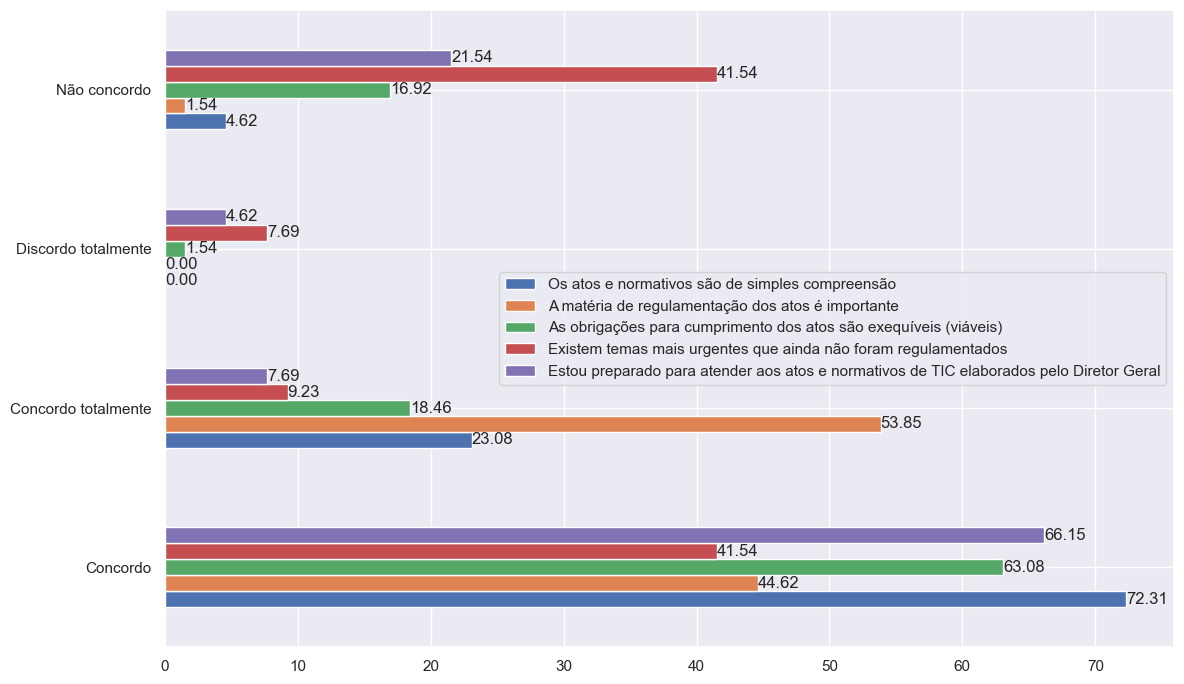

In [172]:
ax = (100*df_secao_setic.filter(regex='^q1036\[SQ').apply(pd.value_counts)/65).plot.barh(figsize=(12, 7))

ax.legend([
    'Os atos e normativos são de simples compreensão', 
    'A matéria de regulamentação dos atos é importante', 
    'As obrigações para cumprimento dos atos são exequíveis (viáveis)', 
    'Existem temas mais urgentes que ainda não foram regulamentados',
    'Estou preparado para atender aos atos e normativos de TIC elaborados pelo Diretor Geral'
])

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()

In [168]:
#1036. Como o Gestor de TI avalia os atos e normativos de TIC elaborados pelo Diretor Geral do SETIC (PRODERJ)
#para cumprimento dos órgãos do nível setorial.

aux = df_secao_setic.filter(regex='q1036').replace({
    'Concordo totalmente': 4, 'Concordo': 3, 'Não concordo': 2, 'Discordo totalmente': 1
})
aux.describe()

,q1036[SQ001],q1036[SQ002],q1036[SQ003],q1036[SQ004],q1036[SQ005]
count,65.000000,65.000000,65.000000,65.000000,65.000000
mean,3.184615,3.523077,2.984615,2.523077,2.769231
std,0.496623,0.533494,0.649334,0.772732,0.655964
min,2.000000,2.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,2.000000
50%,3.000000,4.000000,3.000000,3.000000,3.000000
75%,3.000000,4.000000,3.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000


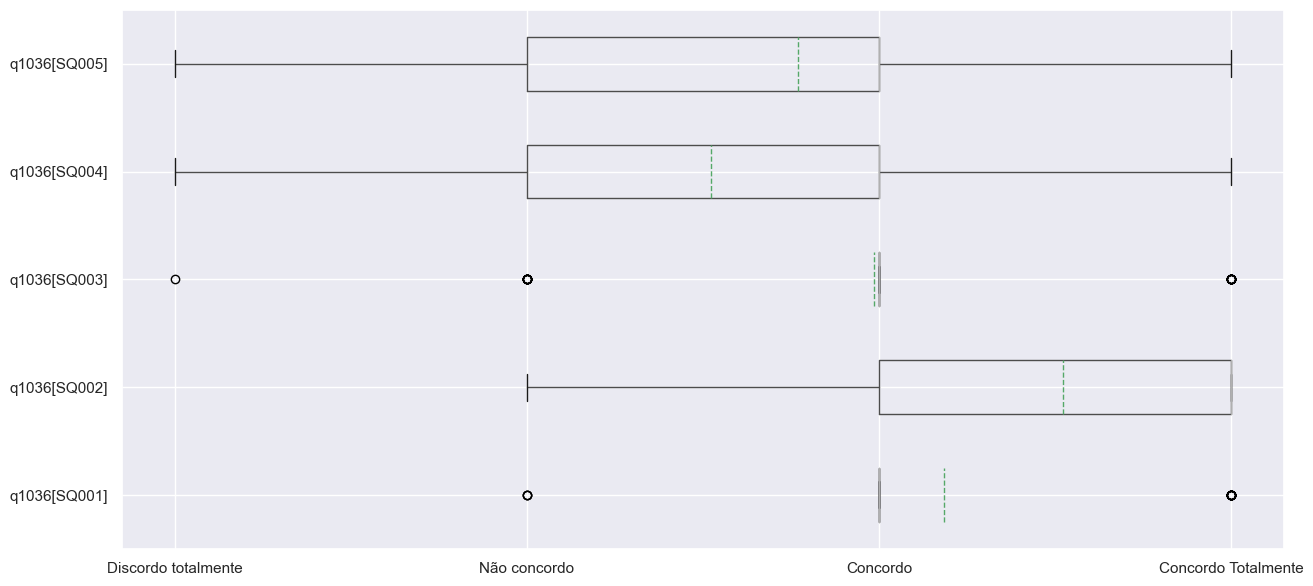

In [170]:
ax = aux.boxplot(showmeans=True, meanline=True, vert=False, figsize=(15, 7))
ax.set_xticks(ticks=[1,2,3,4], labels=['Discordo totalmente', 'Não concordo', 'Concordo', 'Concordo Totalmente'])

### 1037. Para o Gestor de TI, a atuação do Diretor Geral do SETIC (PRODERJ), como integrador de soluções de TIC, atende as necessidades de TIC da organização.


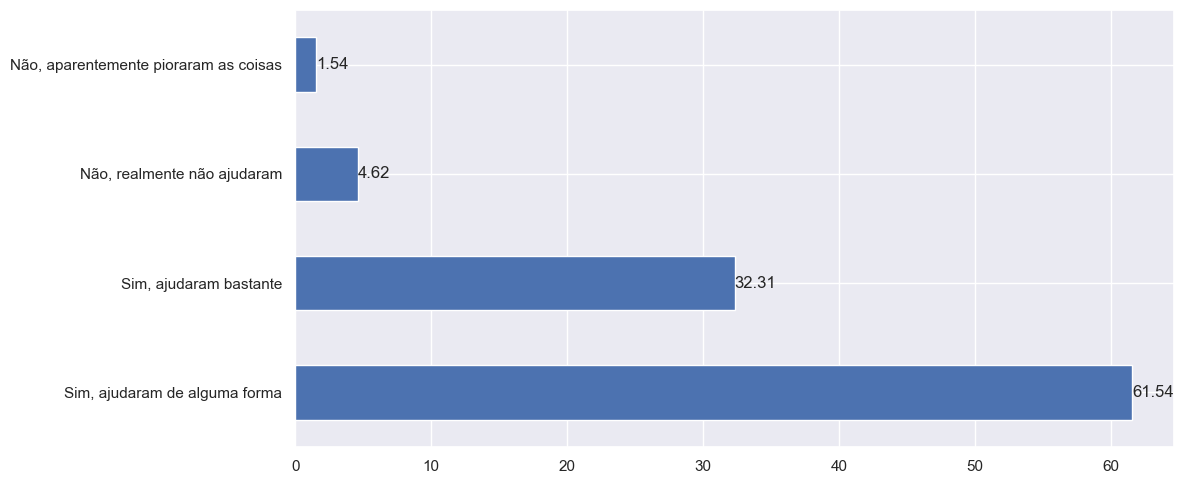

In [174]:
#1037. Para o Gestor de TI, a atuação do Diretor Geral do SETIC (PRODERJ), como integrador de soluções de TIC,
#atende as necessidades de TIC da organização.


ax = ((100*df_secao_setic['q1037'].value_counts()/df_secao_setic['q1037'].count())) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()

In [176]:
df_secao_setic[
    (df_secao_setic['q1037'] == 'Não, realmente não ajudaram') | 
    (df_secao_setic['q1037'] == 'Não, aparentemente pioraram as coisas')
].filter(regex='q1037')

,q1037,q1037raz
attribute_1,,
FSC,"Não, realmente não ajudaram",As normativas elaboradas pelo PRODERJ nem sempre se adequam à realidade limitada existente em todos os órgãos.
SEDEC,"Não, aparentemente pioraram as coisas","Nosso órgão possui muitas especificidades, ficando difícil de ser incluído em uma contratação generalizada. Recentemente tivemos de aderir a uma contratação que não atendia nossas necessidades e nos gerou diversos problemas."
SEPM,"Não, realmente não ajudaram",NaN
UERJ,"Não, realmente não ajudaram","Apesar de conhecer o teor do Decreto Estadual nº 47.278/2020, A DGTI entende que tanto o Decreto quanto os atos normativos não são\naplicáveis à UERJ, tendo em vista a Autonomia didático-científica, administrativa e de gestão\nfinanceira e patrimonial, concedida nos arts. 207 da Constituição da República Federativa do Brasil e 309 da\nConstituição do Estado do Rio de Janeiro. Por este motivo, a UERJ adotou a postura de adequar-se parcialmente,\nlevando em considerando que regulará internamente a temática."


In [177]:
aux = df_secao_setic['q1037']
aux = aux.replace({'Sim, ajudaram bastante': 4, 'Sim, ajudaram de alguma forma': 3, 'Não, realmente não ajudaram': 2, 'Não, aparentemente pioraram as coisas': 1})
aux.describe()

count    65.000000
mean      3.246154
std       0.613157
min       1.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       4.000000
Name: q1037, dtype: float64

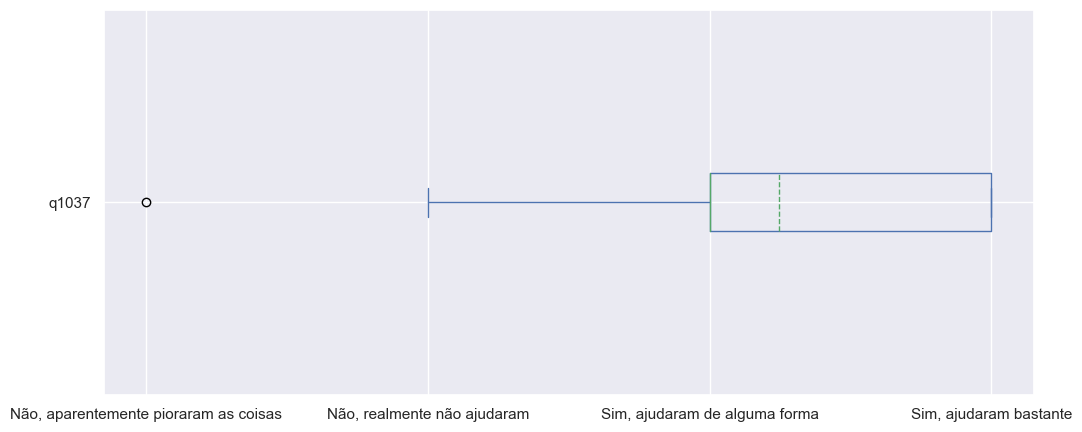

In [179]:
ax = aux.plot.box(showmeans=True, meanline=True, vert=False, figsize=(12, 5))
ax.set_xticks(ticks=[1,2,3,4], labels=['Não, aparentemente pioraram as coisas', 'Não, realmente não ajudaram', 'Sim, ajudaram de alguma forma', 'Sim, ajudaram bastante'])

### 1038. Considerando os meios de comunicação disponíveis, quando necessário, o atendimento prestado pelo Diretor Geral (PRODERJ) ao Gestor de TI supriu as expectativas.


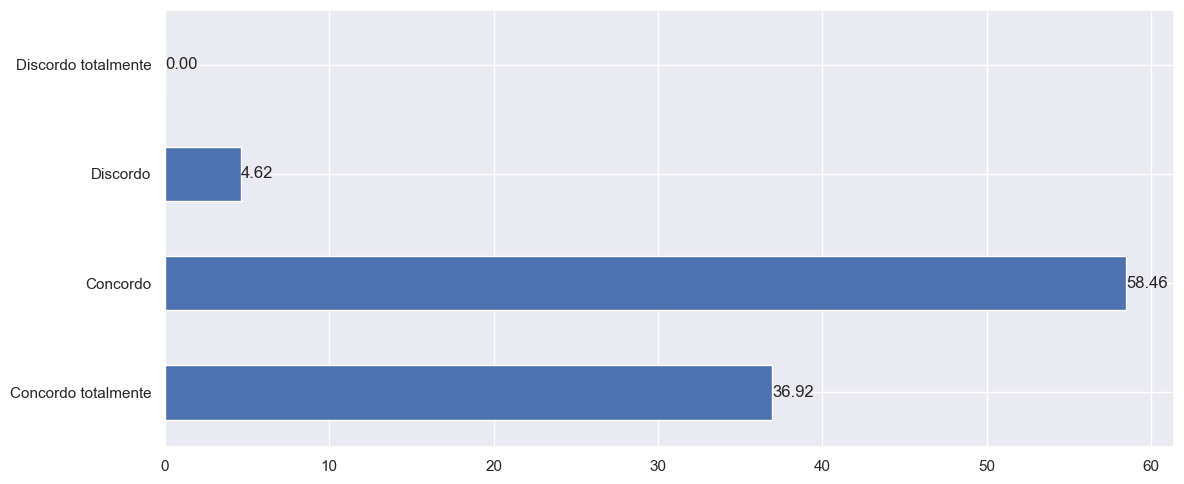

In [181]:
#1038. Considerando os meios de comunicação disponíveis, quando necessário, o atendimento prestado pelo
#Diretor Geral (PRODERJ) ao Gestor de TI supriu as expectativas.

dictionary = {'Concordo totalmente': 0, 'Concordo': 0, 'Discordo': 0, 'Discordo totalmente': 0}
dados = pd.DataFrame.from_dict({**dictionary, **df_secao_setic['q1038'].value_counts().to_dict()}, orient='index')

ax = ((100*dados/df_secao_setic['q1038'].count())) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

ax.get_legend().set_visible(False)

plt.tight_layout()

In [182]:
aux = df_secao_setic.filter(regex='q1038$').replace({
    'Concordo totalmente': 4, 'Concordo': 3, 'Discordo': 2, 'Discordo totalmente': 1
})
aux.describe()

,q1038
count,65.000000
mean,3.323077
std,0.562019
min,2.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,4.000000


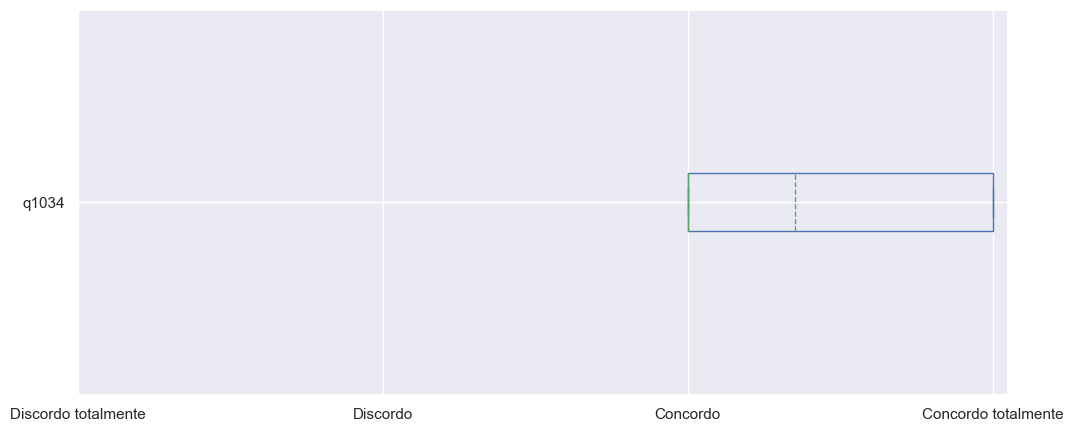

In [191]:
ax = aux.plot.box(showmeans=True, meanline=True, vert=False, figsize=(12, 5))
ax.set_xticks(ticks=[1,2,3,4], labels=['Discordo totalmente', 'Discordo', 'Concordo', 'Concordo totalmente'])

In [184]:
df_secao_setic[
    (df_secao_setic['q1038'] == 'Discordo') | 
    (df_secao_setic['q1038'] == 'Discordo totalmente')
].filter(regex='q1038')

,q1038,q1038raz
attribute_1,,
SEDEC,Discordo,"Apesar do nosso contato com o PRODERJ ser facilitado pelos meios informais, nossa comunicação por meio formal (SEI-RJ) sempre foi muito difícil e demorada, por muitas vezes atrasando nossos processos internos."
AGETRANSP,Discordo,Com a nova gestão da Agência Reguladora estamos buscando maior proximidade com a direção geral do PRODERJ para que venhamos normatizar nossas práticas quanto à gestão de TI. Anteriormente não havia esforços mútuos para o estreitamento do relacionamento entre a AGETRANSP e o PRODERJ.
SEPM,Discordo,NaN


# Coeficiente Alpha de Cronbach do Questionário

In [9]:
import numpy as np
import itertools

df_questoes_setic = df_secao_setic[['q1032', 'q1034', 'q1035', 'q1036[SQ001]','q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ004]', 'q1036[SQ005]', 'q1037', 'q1038']].replace({
    'Muito Satisfeito': 4, 'Muito satisfeito': 4, 'Satisfeito': 3, 'Insatisfeito': 2, 'Muito Insatisfeito': 1, 'Muito insatisfeito': 1,
    'Sim, ajudaram bastante': 4, 'Sim, ajudaram de alguma forma': 3, 'Não, realmente não ajudaram': 2, 'Não, aparentemente pioraram as coisas': 1,
    'Concordo totalmente': 4, 'Concordo': 3, 'Não concordo': 2, 'Discordo totalmente': 1, 'Discordo': 2,
    'Sim, ajudaram bastante': 4, 'Sim, ajudaram de alguma forma': 3, 'Não, realmente não ajudaram': 2, 'Não, aparentemente pioraram as coisas': 1,
    'Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)': np.nan
})

combinations = []

for r in range(len(df_questoes_setic.columns)+1):
    print(r)
    for combination in itertools.combinations(df_questoes_setic.columns, r):
        if len(combination) > 1:
            combinations.append(combination)
            alpha = pg.cronbach_alpha(data=df_questoes_setic[list(combination)])
            if alpha[0] > 0.8:                
                print(alpha, list(combination))            
            #pg.cronbach_alpha(data=df_cron)

print('Dado completo', pg.cronbach_alpha(data=df_questoes_setic))
df_questoes_setic.describe()

0
1
2
3
4
5
(0.800511295234708, array([0.718, 0.865])) ['q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1037']
6
(0.8103212388598565, array([0.734, 0.871])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1037']
(0.8104417488488457, array([0.734, 0.871])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1038']
(0.8087385472847649, array([0.732, 0.869])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ003]', 'q1037', 'q1038']
(0.8104649235323497, array([0.734, 0.871])) ['q1032', 'q1035', 'q1036[SQ002]', 'q1036[SQ003]', 'q1037', 'q1038']
(0.814658468013214, array([0.74 , 0.873])) ['q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1037', 'q1038']
7
(0.8071306473744055, array([0.731, 0.868])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1037']
(0.8049197955380557, array([0.728, 0.866])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1038']
(0.82935503546260

,q1032,q1034,q1035,q1036[SQ001],q1036[SQ002],q1036[SQ003],q1036[SQ004],q1036[SQ005],q1037,q1038
count,59.000000,54.000000,63.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,3.271186,2.962963,3.476190,3.184615,3.523077,2.984615,2.523077,2.769231,3.246154,3.323077
std,0.485319,0.867940,0.618457,0.496623,0.533494,0.649334,0.772732,0.655964,0.613157,0.562019
min,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,4.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


# Análise das perguntas sobre o SETIC no Questionário

Por meio dos dados acima é possível notar que o coeficiente alpha de cronbach maximiza-se quando é feito o processo de purificação, ou eliminação de questões, no processo da análise. 

O resultado é maior com 8 das 10 perguntas propostas, sendo excluídos os itens q1034 e q1036[SQ004].

Com as 10 questões inicialmente propostas atinge-se um valor alpha de 0.681774402337013, num intervalo de confiança de 0.561 a 0.78. O que apresenta um nível moderado de confiança no questionário.

Com o processo de purificação os dados são alpha de 0.8264530712262909, [0.759, 0.881]. O que apresenta um *nível alto* de confiança

### Teste de esferecidade da amostra de Bartlett

In [15]:
chi_square_value,p_value=calculate_bartlett_sphericity(df_questoes_setic.dropna())
chi_square_value, p_value

(132.382377988951, 1.5482856353143834e-10)

In [18]:
subconjunto = ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1037', 'q1038']
chi_square_value,p_value=calculate_bartlett_sphericity(df_questoes_setic[subconjunto].dropna())
chi_square_value, p_value

(143.2502316870379, 1.9979396353757286e-17)

### Teste de esfericidade da amostra de Bartlett: 1.5482856353143834e-10, 

indicando que a amostra é adequada, pois avalia a significância geral de todas as correlações em uma matriz de correlação, sendo requeridos valores de p menores que 0,05. (TCU)

In this Bartlett ’s test, the p-value is 1.5482856353143834e-10. The test was statistically significant, indicating that the observed correlation matrix is not an identity matrix. https://www.datacamp.com/tutorial/introduction-factor-analysis



### Critério de Kaiser-Meyer-Olkin

In [17]:
kmo_all,kmo_model=calculate_kmo(df_questoes_setic.dropna())

kmo_all, kmo_model

(array([0.50611121, 0.38058306, 0.68727293, 0.61812999, 0.61320862,
        0.76195422, 0.40077306, 0.65477679, 0.65193173, 0.61751045]),
 0.6132385761540401)

In [19]:
subconjunto = ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1037', 'q1038']
kmo_all,kmo_model=calculate_kmo(df_questoes_setic[subconjunto].dropna())

kmo_all, kmo_model

(array([0.68664001, 0.89127083, 0.86171081, 0.84903363, 0.77869437,
        0.80753759, 0.75487652, 0.76420558]),
 0.7932241002461508)